# Summarize rebuilt covariates (cohort atlas)

Exploratory QC and manuscript-oriented summaries from the rebuilt person-level
covariate table only:

- Input: `covariates.source_rebuilt.csv.gz` (+ data dictionary) under `tractor_mix/` locally, or the Terra workspace root
- Outputs: inline displays **and** files under `summaries/` (gitignored)

No source exports or individual IDs are written. Small cells (`n < MIN_CELL`)
are redacted in exported crosstabs.


In [ ]:
from pathlib import Path
import os
import subprocess
import sys

# On Terra, localize $WORKSPACE_BUCKET/scripts/ before importing anything.
# Persistent edit/scripts/ copies are often stale and must not win.
_bucket = os.environ.get("WORKSPACE_BUCKET", "").rstrip("/")
_sync = os.environ.get("TERRA_SYNC_SCRIPTS", "true" if _bucket else "").strip().lower() in {
    "1", "true", "yes", "on",
}
_scripts = None
for _d in (Path.cwd() / "scripts", Path.cwd().parent / "scripts", Path.cwd().parent.parent / "scripts"):
    if (_d / "terra_notebook.py").is_file() or (_d / "workspace_paths.py").is_file():
        _scripts = _d.resolve()
        break
if _bucket and _sync:
    if _scripts is None:
        _scripts = (Path.cwd() / "scripts").resolve()
    _scripts.mkdir(parents=True, exist_ok=True)
    print(f"gsutil -m rsync -r {_bucket}/scripts/ {_scripts}/")
    subprocess.check_call(["gsutil", "-m", "rsync", "-r", f"{_bucket}/scripts/", str(_scripts) + "/"])
    os.environ["TERRA_SCRIPTS_LOCALIZED"] = "true"
    import importlib
    importlib.invalidate_caches()
    _prefix = str(_scripts)
    for _name, _mod in list(sys.modules.items()):
        _file = getattr(_mod, "__file__", None)
        if _file and str(_file).startswith(_prefix):
            sys.modules.pop(_name, None)
elif _scripts is None:
    raise FileNotFoundError(
        "scripts/ not found locally and WORKSPACE_BUCKET is unset. "
        "Upload scripts/ to gs://WORKSPACE/scripts/."
    )
sys.path.insert(0, str(_scripts))

from __future__ import annotations

from terra_notebook import init_notebook

SCRIPTS = init_notebook("workspace_paths.py")
from workspace_paths import data_root

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
})

ROOT = data_root()
COV_CSV = ROOT / "covariates.source_rebuilt.csv.gz"
COV_DICT = ROOT / "covariates.source_rebuilt.data_dictionary.tsv"
PHENOTYPE_CSV = ROOT / "resources" / "AoU_Phase2_Phenotype.csv.gz"
OUT_DIR = ROOT / "summaries"
FIG_DIR = OUT_DIR / "figures"
TAB_DIR = OUT_DIR / "tables"
MS_DIR = OUT_DIR / "manuscript"

for d in [OUT_DIR, FIG_DIR, TAB_DIR, MS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MIN_CELL = 20
ARTIFACTS: list[Path] = []

print("ROOT:", ROOT)
print("OUT_DIR:", OUT_DIR)


In [3]:
REQUIRED_COLS = [
    "research_id", "lr_phase", "lr_meet_qc", "lr_releasable_v9",
    "has_rna", "has_proteomics", "has_exposomics", "has_srWGS",
    "age", "sex_at_birth", "zip3", "has_ehr_data", "has_demographics",
    "extraction_method", "has_extraction_method", "has_trgt", "n_trgt_vcfs",
    "population", "ancestry_pred", "ancestry_pred_other", "has_ancestry_annotation",
    "in_pedigree", "pedigree_family_id", "pedigree_is_founder", "pedigree_n_parents",
    "pedigree_family_size", "PC1", "PC2", "has_global_pcs", "has_pop_pcs",
    "in_cdr_v7", "in_cdr_v8", "in_cdr_v9", "has_methylation", "in_phenotype_table",
    "biobank_id", "GC", "technology", "platform", "pb_meth_caller",
    "inferred_sex", "coverage", "coverage_source",
    "is_AIAN", "withdrawn", "unavailable",
    "final_releasable_v9", "in_final_set", "n_final_rows", "has_lr_tech",
    "has_ONT", "has_PacBio", "n_lr_technical_rows", "techs_available",
    "has_sv_counts", "n_sv_del", "n_sv_ins",
    "asm_len_hap1", "asm_len_hap2", "asm_len_diploid",
    "asm_aun_hap1", "asm_aun_hap2", "asm_aun_mean", "has_asm_metrics",
    "phase1_asm_len_p_ctg", "phase1_asm_len_hap1", "phase1_asm_len_hap2", "phase1_asm_len_diploid",
    "phase1_asm_n_contigs_p_ctg", "phase1_asm_n_contigs_hap1", "phase1_asm_n_contigs_hap2", "phase1_asm_n_contigs_diploid",
    "phase1_asm_n50_p_ctg", "phase1_asm_n50_hap1", "phase1_asm_n50_hap2", "phase1_asm_n50_hap_mean",
    "phase1_asm_aun_p_ctg", "phase1_asm_aun_hap1", "phase1_asm_aun_hap2", "phase1_asm_aun_mean", "has_phase1_asm_metrics",
    "phase2_asm_len_p_ctg", "phase2_asm_len_hap1", "phase2_asm_len_hap2", "phase2_asm_len_diploid",
    "phase2_asm_n_contigs_p_ctg", "phase2_asm_n_contigs_hap1", "phase2_asm_n_contigs_hap2", "phase2_asm_n_contigs_diploid",
    "phase2_asm_n50_p_ctg", "phase2_asm_n50_hap1", "phase2_asm_n50_hap2", "phase2_asm_n50_hap_mean",
    "phase2_asm_aun_p_ctg", "phase2_asm_aun_hap1", "phase2_asm_aun_hap2", "phase2_asm_aun_mean", "has_phase2_asm_metrics",
    "phase1_mosdepth_cov", "phase1_aligned_num_bases", "phase1_aligned_num_reads",
    "phase1_read_length_n50", "phase1_read_length_mean", "phase1_read_length_stdev",
    "phase1_average_identity", "phase1_median_identity",
    "phase1_n_snv_pass", "phase1_n_sv_pbsv", "phase1_n_sv_sniffles", "has_phase1_aux_metrics",
]

BOOL_COLS = [
    "lr_meet_qc", "lr_releasable_v9", "rna_meet_qc", "has_rna",
    "proteomics_meet_qc", "has_proteomics", "has_exposomics", "has_srWGS",
    "has_demographics", "has_extraction_method", "has_trgt",
    "has_global_pcs", "has_pop_pcs", "in_cdr_v7", "in_cdr_v8", "in_cdr_v9",
    "has_methylation", "in_phenotype_table", "is_AIAN", "withdrawn",
    "unavailable", "final_releasable_v9", "in_final_set", "has_lr_tech",
    "has_ONT", "has_PacBio", "has_asm_metrics", "has_phase1_asm_metrics", "has_phase2_asm_metrics", "has_phase1_aux_metrics", "has_ancestry_annotation", "in_pedigree",
    "pedigree_is_founder",
]

df = pd.read_csv(COV_CSV, dtype={"research_id": str, "biobank_id": str, "zip3": str}, low_memory=False)
missing = [c for c in REQUIRED_COLS if c not in df.columns]
assert not missing, f"missing required columns: {missing}"
assert df["research_id"].is_unique

data_dictionary = pd.read_csv(COV_DICT, sep="\t")
assert set(REQUIRED_COLS).issubset(set(data_dictionary["column"]))

for c in BOOL_COLS:
    if c in df.columns:
        # nullable object bools (e.g. has_ehr_data) stay nullable
        if c == "has_ehr_data":
            df[c] = df[c].map({True: True, False: False, "True": True, "False": False})
        else:
            df[c] = df[c].fillna(False).astype(bool)

df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["coverage"] = pd.to_numeric(df["coverage"], errors="coerce")
for i in range(1, 33):
    if f"PC{i}" in df.columns:
        df[f"PC{i}"] = pd.to_numeric(df[f"PC{i}"], errors="coerce")
    if f"pop_PC{i}" in df.columns:
        df[f"pop_PC{i}"] = pd.to_numeric(df[f"pop_PC{i}"], errors="coerce")

N = len(df)
print(f"Loaded {N:,} people × {df.shape[1]} columns")
display(data_dictionary.head(12))


Loaded 17,226 people × 109 columns


,column,source,notes
0,research_id,multiomics research_id,primary key
1,lr_phase,multiomics long_read phase,phase_1 / phase_2 / phase_1_phase_2
2,lr_meet_qc,multiomics long_read meet QC,bool; blank→False
3,lr_releasable_v9,multiomics long_read releasable v9,bool; blank→False
4,rna_meet_qc,multiomics RNASeq meet QC,bool; blank→False
5,has_rna,multiomics RNASeq releasable,v3-compatible
6,proteomics_meet_qc,multiomics Proteomics meet QC,bool; blank→False
7,has_proteomics,multiomics Proteomics releasable,v3-compatible
8,has_exposomics,multiomics Exposomics releasable v9,bool; blank→False
9,has_srWGS,multiomics rid_no_srWGS,True unless source marks person as lacking sho...


In [4]:
def save_table(frame: pd.DataFrame, name: str, *, manuscript: bool = False) -> Path:
    dest_dir = MS_DIR if manuscript else TAB_DIR
    path = dest_dir / f"{name}.tsv"
    frame.to_csv(path, sep="\t", index=False)
    ARTIFACTS.append(path)
    print(f"wrote {path.relative_to(ROOT)} ({len(frame):,} rows)")
    return path


def save_fig(fig: plt.Figure, name: str) -> Path:
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, bbox_inches="tight")
    ARTIFACTS.append(path)
    print(f"wrote {path.relative_to(ROOT)}")
    return path


def redact_small(frame: pd.DataFrame, min_cell: int = MIN_CELL) -> pd.DataFrame:
    """Replace counts below min_cell with NA for export safety."""
    out = frame.copy()
    numeric = out.select_dtypes(include=[np.number])
    for col in numeric.columns:
        mask = out[col].notna() & (out[col] < min_cell) & (out[col] > 0)
        out.loc[mask, col] = np.nan
    return out


def count_flag(series: pd.Series) -> dict:
    s = series.fillna(False)
    return {"n_true": int(s.sum()), "n_false": int((~s.astype(bool)).sum()), "frac_true": float(s.mean())}


def value_counts_table(series: pd.Series, name: str) -> pd.DataFrame:
    vc = series.fillna("NA").astype(str).value_counts(dropna=False)
    out = vc.rename_axis(name).reset_index(name="n")
    out["frac"] = out["n"] / out["n"].sum()
    return out


def missingness_table(frame: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    rows = []
    for c in cols:
        n_miss = int(frame[c].isna().sum())
        rows.append({"column": c, "n_missing": n_miss, "frac_missing": n_miss / len(frame)})
    return pd.DataFrame(rows).sort_values("frac_missing", ascending=False)


def is_present(series: pd.Series) -> pd.Series:
    """Non-missing representation: NA / NaN / empty string count as absent."""
    if pd.api.types.is_string_dtype(series) or series.dtype == object:
        s = series.astype("string")
        return s.notna() & s.str.strip().ne("")
    return series.notna()


def column_completeness_by_phase(
    frame: pd.DataFrame,
    phase_col: str = "lr_phase",
    phases: list[str] | None = None,
) -> pd.DataFrame:
    """Per-column non-missing rates (and True rates for bools) by lr_phase."""
    if phases is None:
        phases = ["phase_1", "phase_1_phase_2", "phase_2"]
    phase = frame[phase_col].fillna("NA").astype(str)
    cols = [c for c in frame.columns if c != phase_col]
    rows = []
    for column in cols:
        series = frame[column]
        present = is_present(series)
        is_bool = (
            column in BOOL_COLS
            or pd.api.types.is_bool_dtype(series)
            or set(series.dropna().unique()).issubset({True, False, 0, 1})
        )
        row: dict = {"column": column, "is_bool_like": bool(is_bool)}
        fracs = []
        for p in phases:
            mask = phase == p
            n = int(mask.sum())
            n_present = int(present[mask].sum())
            frac = (n_present / n) if n else np.nan
            row[f"{p}_n"] = n
            row[f"{p}_n_present"] = n_present
            row[f"{p}_frac_present"] = frac
            fracs.append(frac)
            if is_bool:
                true_rate = float(series[mask].fillna(False).astype(bool).mean()) if n else np.nan
                row[f"{p}_frac_true"] = true_rate
        finite = [f for f in fracs if pd.notna(f)]
        row["min_frac_present"] = float(min(finite)) if finite else np.nan
        row["max_frac_present"] = float(max(finite)) if finite else np.nan
        row["range_frac_present"] = (
            row["max_frac_present"] - row["min_frac_present"] if finite else np.nan
        )
        rows.append(row)
    out = pd.DataFrame(rows)
    return out.sort_values(
        ["range_frac_present", "min_frac_present", "column"],
        ascending=[False, True, True],
    ).reset_index(drop=True)


# Shared analysis subsets
available = df.loc[~df["withdrawn"] & ~df["unavailable"]].copy()
lr_tech = df.loc[df["has_lr_tech"]].copy()
releasable = df.loc[df["final_releasable_v9"] & ~df["withdrawn"]].copy()
print({
    "universe": N,
    "not_withdrawn_unavailable": len(available),
    "has_lr_tech": len(lr_tech),
    "final_releasable_v9_not_withdrawn": len(releasable),
})


{'universe': 17226, 'not_withdrawn_unavailable': 17094, 'has_lr_tech': 13530, 'final_releasable_v9_not_withdrawn': 13530}


## 1. Cohort flow and availability

Universe = all multiomics-list people. Status flags (`withdrawn`, `unavailable`,
`final_releasable_v9`) come from the Steve final-set. Modality flags are
person-level availability indicators, not trait ascertainment.


,metric,n,frac_of_universe
0,universe,17226,1.000000
1,in_final_set,13662,0.793103
2,withdrawn,123,0.007140
3,unavailable,9,0.000522
4,final_releasable_v9,13530,0.785441
5,has_lr_tech,13530,0.785441
6,lr_meet_qc,14675,0.851910
7,lr_releasable_v9,14521,0.842970
8,in_ont_v9,2144,0.124463
9,in_pacbio_v9,12261,0.711773


wrote summaries/manuscript/cohort_flow_summary.tsv (13 rows)


,modality,n_true,n_false,n_na,frac_true
0,has_srWGS,17203,23,0,0.998665
1,has_methylation,13662,3564,0,0.793103
2,has_rna,8980,8246,0,0.521305
3,has_proteomics,9969,7257,0,0.578718
4,has_exposomics,5636,11590,0,0.327180
5,has_trgt,12392,4834,0,0.719378
6,in_phenotype_table,9953,7273,0,0.577789
7,has_ehr_data,15070,2007,149,0.874840


wrote summaries/manuscript/modality_availability.tsv (8 rows)
wrote summaries/figures/cohort_flow_and_modality.png


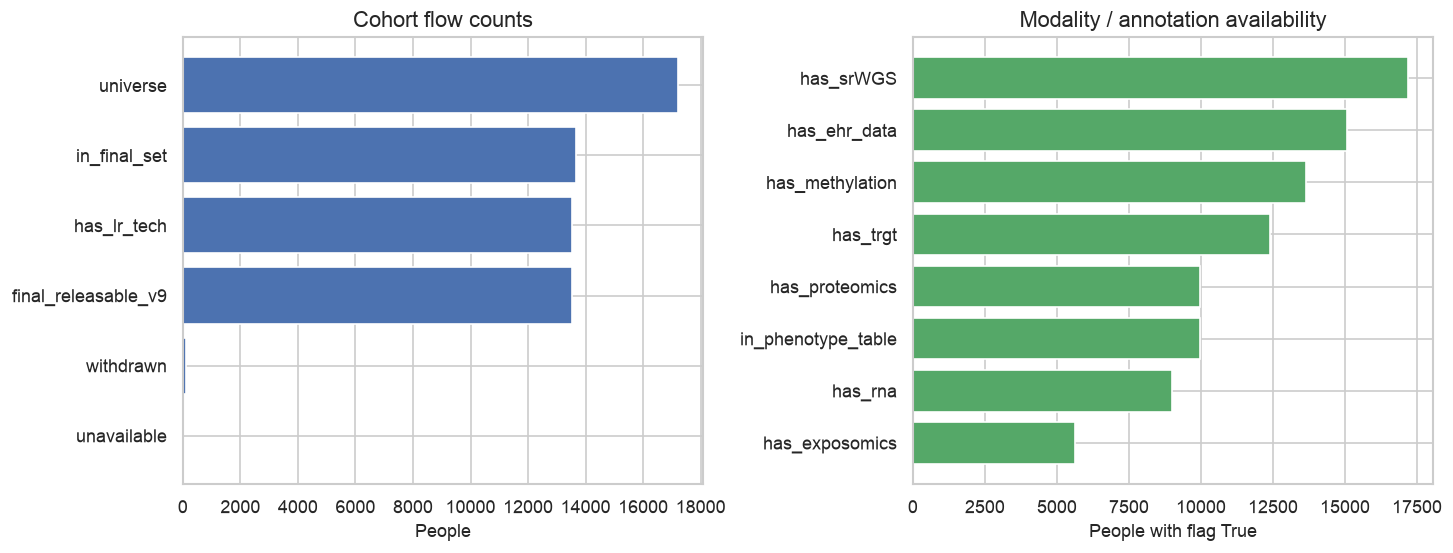

In [5]:
cohort_rows = [

    {"metric": "universe", "n": N, "frac_of_universe": 1.0},

    {"metric": "in_final_set", "n": int(df["in_final_set"].sum()), "frac_of_universe": df["in_final_set"].mean()},

    {"metric": "withdrawn", "n": int(df["withdrawn"].sum()), "frac_of_universe": df["withdrawn"].mean()},

    {"metric": "unavailable", "n": int(df["unavailable"].sum()), "frac_of_universe": df["unavailable"].mean()},

    {"metric": "final_releasable_v9", "n": int(df["final_releasable_v9"].sum()), "frac_of_universe": df["final_releasable_v9"].mean()},

    {"metric": "has_lr_tech", "n": int(df["has_lr_tech"].sum()), "frac_of_universe": df["has_lr_tech"].mean()},

    {"metric": "lr_meet_qc", "n": int(df["lr_meet_qc"].sum()), "frac_of_universe": df["lr_meet_qc"].mean()},

    {"metric": "lr_releasable_v9", "n": int(df["lr_releasable_v9"].sum()), "frac_of_universe": df["lr_releasable_v9"].mean()},

    {"metric": "has_ONT", "n": int(df["has_ONT"].sum()), "frac_of_universe": df["has_ONT"].mean()},

    {"metric": "has_PacBio", "n": int(df["has_PacBio"].sum()), "frac_of_universe": df["has_PacBio"].mean()},

    {"metric": "has_ancestry_annotation", "n": int(df["has_ancestry_annotation"].sum()), "frac_of_universe": df["has_ancestry_annotation"].mean()},

    {"metric": "in_pedigree", "n": int(df["in_pedigree"].sum()), "frac_of_universe": df["in_pedigree"].mean()},

    {"metric": "in_cdr_v7", "n": int(df["in_cdr_v7"].sum()), "frac_of_universe": df["in_cdr_v7"].mean()},

    {"metric": "in_cdr_v8", "n": int(df["in_cdr_v8"].sum()), "frac_of_universe": df["in_cdr_v8"].mean()},

    {"metric": "in_cdr_v9", "n": int(df["in_cdr_v9"].sum()), "frac_of_universe": df["in_cdr_v9"].mean()},

]

cohort_summary = pd.DataFrame(cohort_rows)

display(cohort_summary)

save_table(cohort_summary, "cohort_flow_summary", manuscript=True)



modality_flags = [

    "has_srWGS", "has_methylation", "has_rna", "has_proteomics",

    "has_exposomics", "has_trgt", "in_phenotype_table", "has_ehr_data",

]

modality_rows = []

for c in modality_flags:

    s = df[c]

    if c == "has_ehr_data":

        n_true = int(s.fillna(False).astype(bool).sum())

        n_na = int(s.isna().sum())

        modality_rows.append({

            "modality": c, "n_true": n_true, "n_false": N - n_true - n_na,

            "n_na": n_na, "frac_true": n_true / N,

        })

    else:

        modality_rows.append({

            "modality": c, "n_true": int(s.sum()), "n_false": int((~s).sum()),

            "n_na": 0, "frac_true": float(s.mean()),

        })

modality_summary = pd.DataFrame(modality_rows)

display(modality_summary)

save_table(modality_summary, "modality_availability", manuscript=True)



fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

cohort_plot = cohort_summary.set_index("metric")["n"].loc[

    ["universe", "in_final_set", "has_lr_tech", "final_releasable_v9", "withdrawn", "unavailable"]

]

axes[0].barh(cohort_plot.index[::-1], cohort_plot.values[::-1], color="#4C72B0")

axes[0].set_xlabel("People")

axes[0].set_title("Cohort flow counts")

axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))



mod_plot = modality_summary.set_index("modality")["n_true"].sort_values()

axes[1].barh(mod_plot.index, mod_plot.values, color="#55A868")

axes[1].set_xlabel("People with flag True")

axes[1].set_title("Modality / annotation availability")

save_fig(fig, "cohort_flow_and_modality")

plt.show()

plt.close('all')



,lr_phase,n,frac
0,phase_2,13648,0.792291
1,NA,2551,0.148090
2,phase_1,1013,0.058806
3,phase_1_phase_2,14,0.000813


,technology,n,frac
0,PacBio,12261,0.711773
1,NA,3696,0.214559
2,ONT,1269,0.073668


,cdr_membership,n,frac
0,v9_only,11744,0.681760
1,none,2682,0.155695
2,mixed_other,1794,0.104145
3,v7+v8+v9,1005,0.058342
4,v8_only,1,0.000058


wrote summaries/manuscript/lr_phase_counts.tsv (4 rows)
wrote summaries/manuscript/technology_counts.tsv (3 rows)
wrote summaries/tables/cdr_membership_pattern_counts.tsv (5 rows)


unavailable,False,True,All
withdrawn,,,
False,17094,9,17103
True,123,0,123
All,17217,9,17226


wrote summaries/tables/withdrawn_unavailable_crosstab.tsv (3 rows)
wrote summaries/figures/phase_technology_cdr.png


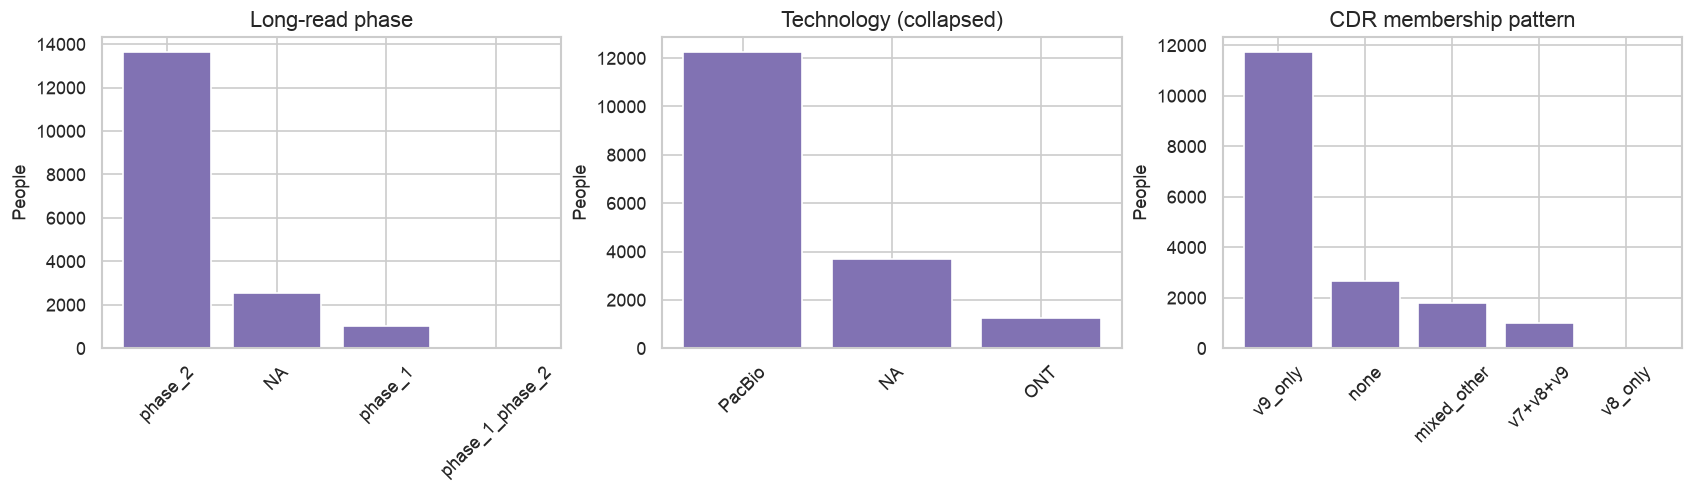

In [6]:
phase_tab = value_counts_table(df["lr_phase"], "lr_phase")

tech_tab = value_counts_table(df["technology"], "technology")

cdr_combo = (

    df.assign(

        cdr_membership=np.select(

            [

                df["in_cdr_v7"] & df["in_cdr_v8"] & df["in_cdr_v9"],

                df["in_cdr_v9"] & ~df["in_cdr_v7"] & ~df["in_cdr_v8"],

                df["in_cdr_v8"] & ~df["in_cdr_v7"] & ~df["in_cdr_v9"],

                df["in_cdr_v7"] & ~df["in_cdr_v8"] & ~df["in_cdr_v9"],

                (df["in_cdr_v7"] | df["in_cdr_v8"] | df["in_cdr_v9"]),

            ],

            ["v7+v8+v9", "v9_only", "v8_only", "v7_only", "mixed_other"],

            default="none",

        )

    )

)

cdr_tab = value_counts_table(cdr_combo["cdr_membership"], "cdr_membership")

display(phase_tab)

display(tech_tab)

display(cdr_tab)

save_table(phase_tab, "lr_phase_counts", manuscript=True)

save_table(tech_tab, "technology_counts", manuscript=True)

save_table(cdr_tab, "cdr_membership_pattern_counts")



status_ct = pd.crosstab(df["withdrawn"], df["unavailable"], margins=True)

display(status_ct)

save_table(status_ct.reset_index(), "withdrawn_unavailable_crosstab")



fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

for ax, tab, title, col in [

    (axes[0], phase_tab, "Long-read phase", "lr_phase"),

    (axes[1], tech_tab, "Technology (collapsed)", "technology"),

    (axes[2], cdr_tab, "CDR membership pattern", "cdr_membership"),

]:

    ax.bar(tab[col].astype(str), tab["n"], color="#8172B3")

    ax.set_title(title)

    ax.set_ylabel("People")

    ax.tick_params(axis="x", rotation=45)

save_fig(fig, "phase_technology_cdr")

plt.show()

plt.close('all')



## 2. Demographics and completeness

ZIP3 is summarized only as completeness (fraction non-missing), not as a
geography crosstab, to avoid small-cell disclosure.


,column,n_missing,frac_missing
5,inferred_sex,3696,0.214559
0,age,149,0.008650
1,sex_at_birth,149,0.008650
2,zip3,149,0.008650
3,has_ehr_data,149,0.008650
4,has_demographics,0,0.000000


wrote summaries/manuscript/demographics_missingness.tsv (6 rows)


,stat,value
0,count,17077.000000
1,mean,53.708848
2,std,16.927197
3,min,21.000000
4,5%,27.000000
5,25%,39.000000
6,50%,55.000000
7,75%,67.000000
8,95%,81.000000
9,max,90.000000


wrote summaries/manuscript/age_summary_stats.tsv (10 rows)


,sex_at_birth,n,frac
0,Female,9489,0.550853
1,Male,6975,0.404911
2,PMI: Skip,428,0.024846
3,NA,149,0.008650
4,I prefer not to answer,114,0.006618
5,Sex At Birth: Sex At Birth None Of These,43,0.002496
6,Intersex,28,0.001625


,inferred_sex,n,frac
0,XX,7649,0.444038
1,XY,5799,0.336642
2,NA,3696,0.214559
3,X,71,0.004122
4,XXX,6,0.000348
5,XXY,4,0.000232
6,XYY,1,0.000058


wrote summaries/manuscript/sex_at_birth_counts.tsv (7 rows)
wrote summaries/tables/inferred_sex_counts.tsv (7 rows)


,metric,n,frac,n_unique_non_missing
0,zip3_non_missing,17077,0.99135,423


wrote summaries/manuscript/zip3_completeness_only.tsv (1 rows)
wrote summaries/figures/age_and_sex.png


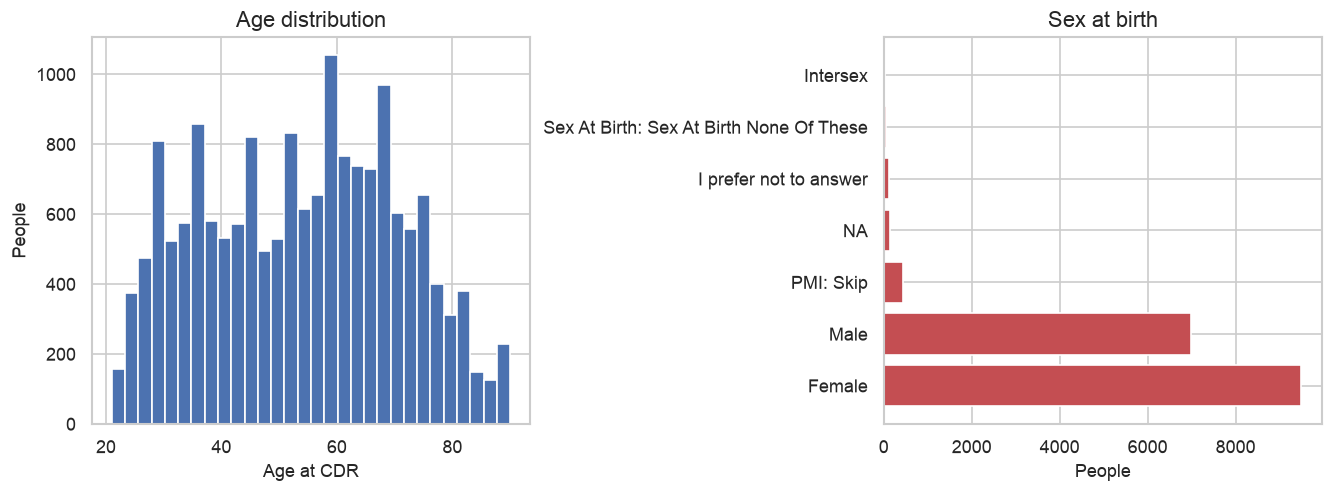

lr_phase,NA,phase_1,phase_1_phase_2,phase_2,All
sex_at_birth,,,,,
Female,1379,696,12,7402,9489
I prefer not to answer,4,0,0,110,114
Intersex,2,1,0,25,28
Male,1110,287,2,5576,6975
NA,16,22,0,111,149
PMI: Skip,37,7,0,384,428
Sex At Birth: Sex At Birth None Of These,3,0,0,40,43
All,2551,1013,14,13648,17226


wrote summaries/tables/sex_by_phase_crosstab_redacted.tsv (8 rows)


PosixPath('/Users/kiran/repositories/aou-lr-phase-2/tractor_mix/summaries/tables/sex_by_phase_crosstab_redacted.tsv')

In [7]:
demo_cols = ["age", "sex_at_birth", "zip3", "has_ehr_data", "has_demographics", "inferred_sex"]

demo_miss = missingness_table(df, demo_cols)

display(demo_miss)

save_table(demo_miss, "demographics_missingness", manuscript=True)



age_stats = df["age"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).rename("age").reset_index()

age_stats.columns = ["stat", "value"]

display(age_stats)

save_table(age_stats, "age_summary_stats", manuscript=True)



sex_tab = value_counts_table(df["sex_at_birth"], "sex_at_birth")

inferred_tab = value_counts_table(df["inferred_sex"], "inferred_sex")

display(sex_tab)

display(inferred_tab)

save_table(sex_tab, "sex_at_birth_counts", manuscript=True)

save_table(inferred_tab, "inferred_sex_counts")



zip3_complete = pd.DataFrame([{

    "metric": "zip3_non_missing",

    "n": int(df["zip3"].notna().sum()),

    "frac": float(df["zip3"].notna().mean()),

    "n_unique_non_missing": int(df.loc[df["zip3"].notna(), "zip3"].nunique()),

}])

display(zip3_complete)

save_table(zip3_complete, "zip3_completeness_only", manuscript=True)



fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

axes[0].hist(df["age"].dropna(), bins=30, color="#4C72B0", edgecolor="white")

axes[0].set_xlabel("Age at CDR")

axes[0].set_ylabel("People")

axes[0].set_title("Age distribution")

sex_plot = sex_tab.copy()

axes[1].barh(sex_plot["sex_at_birth"], sex_plot["n"], color="#C44E52")

axes[1].set_xlabel("People")

axes[1].set_title("Sex at birth")

save_fig(fig, "age_and_sex")

plt.show()

plt.close('all')



# Sex × phase (redact small cells on export)

sex_phase = pd.crosstab(df["sex_at_birth"].fillna("NA"), df["lr_phase"].fillna("NA"), margins=True)

display(sex_phase)

save_table(redact_small(sex_phase.reset_index()), "sex_by_phase_crosstab_redacted")



## 2b. Column completeness by long-read phase

For every covariate column, fraction with a non-missing value in
`phase_1`, `phase_1_phase_2`, and `phase_2`. Boolean / flag columns are
usually complete (True/False); for those, `*_frac_true` is the more useful
sense of “representation.”


In [ ]:
PHASES = ["phase_1", "phase_1_phase_2", "phase_2"]
phase_complete = column_completeness_by_phase(df, phases=PHASES)

# People with unlabeled lr_phase are excluded from the three phase columns above;
# report their count separately for context.
n_phase_na = int(df["lr_phase"].isna().sum())
print(f"People with missing lr_phase (excluded from phase columns): {n_phase_na:,}")
print(f"Columns scored: {len(phase_complete):,}")

display(
    phase_complete[
        [
            "column",
            "is_bool_like",
            "phase_1_frac_present",
            "phase_1_phase_2_frac_present",
            "phase_2_frac_present",
            "min_frac_present",
            "range_frac_present",
        ]
    ].head(40)
)

save_table(phase_complete, "column_completeness_by_lr_phase", manuscript=True)

# Long form for heatmap / manuscript-friendly filtering
long_rows = []
for _, r in phase_complete.iterrows():
    for p in PHASES:
        long_rows.append({
            "column": r["column"],
            "is_bool_like": r["is_bool_like"],
            "lr_phase": p,
            "n": r[f"{p}_n"],
            "n_present": r[f"{p}_n_present"],
            "frac_present": r[f"{p}_frac_present"],
            "frac_true": r.get(f"{p}_frac_true", np.nan),
        })
phase_complete_long = pd.DataFrame(long_rows)
save_table(phase_complete_long, "column_completeness_by_lr_phase_long")

# Highlight columns that are uneven across phases (present-rate range > 5%)
uneven = phase_complete.loc[phase_complete["range_frac_present"] > 0.05].copy()
display(uneven[[
    "column", "phase_1_frac_present", "phase_1_phase_2_frac_present",
    "phase_2_frac_present", "range_frac_present",
]])
save_table(uneven, "column_completeness_by_lr_phase_uneven", manuscript=True)

# Boolean flags are usually complete (True/False); True-rate is the useful
# cross-phase consistency metric for those columns.
bool_rates = phase_complete.loc[phase_complete["is_bool_like"]].copy()
true_cols = [f"{p}_frac_true" for p in PHASES]
bool_rates["range_frac_true"] = bool_rates[true_cols].max(axis=1) - bool_rates[true_cols].min(axis=1)
bool_uneven = bool_rates.loc[bool_rates["range_frac_true"] > 0.05].sort_values(
    "range_frac_true", ascending=False
)
display(bool_uneven[["column", *true_cols, "range_frac_true"]])
save_table(bool_uneven, "column_true_rate_by_lr_phase_uneven", manuscript=True)

# Heatmap of present fraction (drop near-constant complete bool IDs for readability:
# keep columns with any missingness OR any cross-phase range, plus a few key flags)
plot_cols = phase_complete.loc[
    (phase_complete["min_frac_present"] < 0.999)
    | (phase_complete["range_frac_present"] > 0.01)
    | phase_complete["column"].isin([
        "coverage", "GC", "technology", "platform", "extraction_method",
        "has_lr_tech", "has_PacBio", "has_ONT", "has_methylation",
        "has_sv_counts", "has_global_pcs",
        "ancestry_pred", "in_pedigree", "in_phenotype_table",
    ])
, "column"].tolist()

heat = (
    phase_complete_long.loc[phase_complete_long["column"].isin(plot_cols)]
    .pivot(index="column", columns="lr_phase", values="frac_present")
    .reindex(columns=PHASES)
    .reindex(plot_cols)
)

fig, ax = plt.subplots(figsize=(8, max(6, 0.22 * len(heat))), constrained_layout=True)
sns.heatmap(
    heat,
    ax=ax,
    vmin=0,
    vmax=1,
    cmap="viridis",
    linewidths=0.2,
    linecolor="white",
    cbar_kws={"label": "Fraction non-missing"},
)
ax.set_title("Covariate completeness by long-read phase")
ax.set_xlabel("lr_phase")
ax.set_ylabel("column")
save_fig(fig, "column_completeness_by_lr_phase")
plt.show()
plt.close("all")


## 3. Technical characterization

Coverage, genome center (`GC`), extraction method, platform, and methylation
caller among people with long-read technical fields.


,column,n_missing,frac_missing
4,pb_meth_caller,4965,0.288227
0,coverage,3696,0.214559
1,GC,3696,0.214559
2,technology,3696,0.214559
3,platform,3696,0.214559
5,extraction_method,2705,0.157030
6,has_lr_tech,0,0.000000


wrote summaries/tables/technical_missingness.tsv (7 rows)


,stat,value
0,count,13530.000000
1,mean,19.439301
2,std,7.798526
3,min,7.410000
4,5%,11.680000
5,25%,14.190000
6,50%,16.875000
7,75%,21.150000
8,95%,36.160000
9,max,65.250000


,technology,count,mean,std,min,25%,50%,75%,max
0,NA,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ONT,1269.0,34.513704,5.929749,20.00,30.26,33.98,37.74,65.25
2,PacBio,12261.0,17.879117,6.125376,7.41,13.96,16.37,19.44,51.09


wrote summaries/manuscript/coverage_summary_stats.tsv (10 rows)
wrote summaries/manuscript/coverage_by_technology.tsv (3 rows)


...

wrote summaries/tables/platform_counts.tsv (4 rows)


,pb_meth_caller,n,frac
0,jasmine-2.2.0,7124,0.413561
1,NA,4965,0.288227
2,primrose-1.4.0,3832,0.222454
3,primrose-1.2.0,1217,0.070649
4,mixed,88,0.005109


wrote summaries/tables/pb_meth_caller_counts.tsv (5 rows)


,techs_available,n,frac
0,PacBio,11386,0.660978
1,NA,3696,0.214559
2,ONT,1269,0.073668
3,ONT|PacBio,875,0.050795


wrote summaries/tables/techs_available_counts.tsv (4 rows)
wrote summaries/figures/technical_coverage_gc_extraction.png


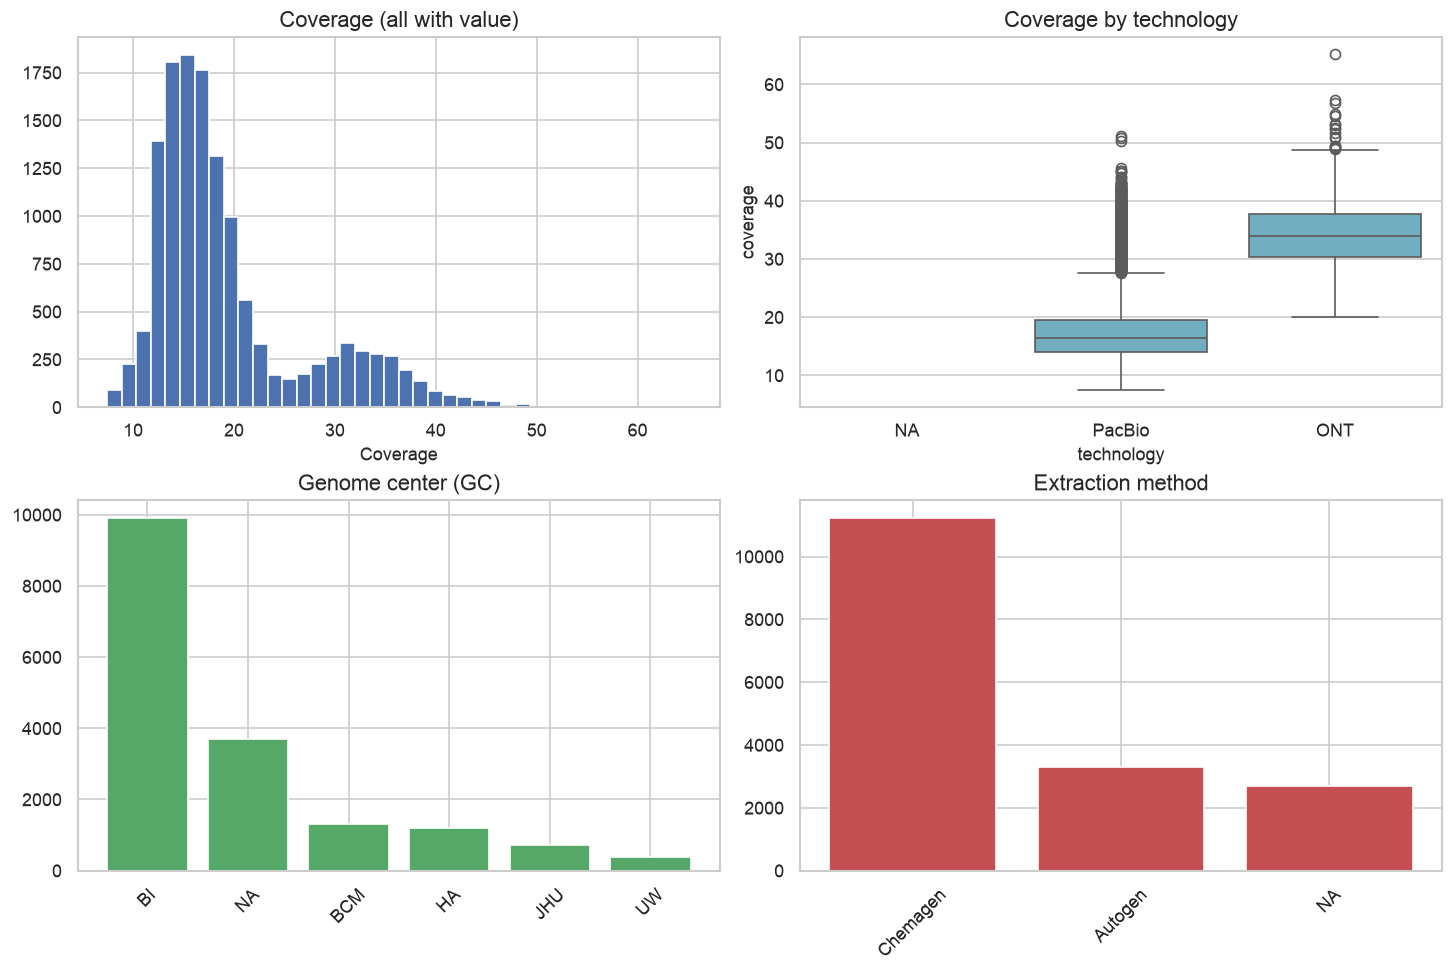

wrote summaries/figures/platform_and_techs_available.png


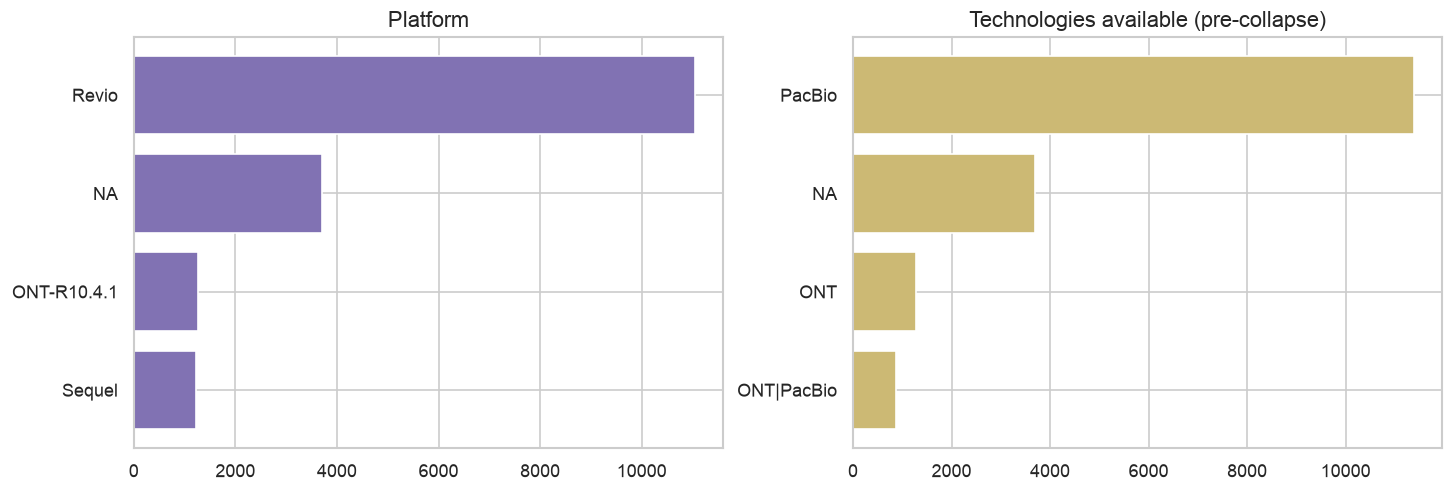

,n_lr_rows,n,frac
0,1.0,12651,0.734413
1,NA,3696,0.214559
2,2.0,855,0.049634
3,3.0,24,0.001393


,n_final_rows,n,frac
0,1,12775,0.741612
1,0,3564,0.206897
2,2,863,0.050099
3,3,24,0.001393


wrote summaries/tables/n_lr_rows_counts.tsv (4 rows)
wrote summaries/tables/n_final_rows_counts.tsv (4 rows)


PosixPath('/Users/kiran/repositories/aou-lr-phase-2/tractor_mix/summaries/tables/n_final_rows_counts.tsv')

In [8]:
tech_miss = missingness_table(

    df,

    [
        "coverage", "coverage_source", "GC", "technology", "platform",
        "pb_meth_caller", "extraction_method", "has_lr_tech",
    ],

)

display(tech_miss)

save_table(tech_miss, "technical_missingness")



cov_stats = df["coverage"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).rename("coverage").reset_index()

cov_stats.columns = ["stat", "value"]

cov_by_tech = (

    df.groupby(df["technology"].fillna("NA"), dropna=False)["coverage"]

    .describe(percentiles=[0.25, 0.5, 0.75])

    .reset_index()

)

display(cov_stats)

display(cov_by_tech)

save_table(cov_stats, "coverage_summary_stats", manuscript=True)

save_table(cov_by_tech, "coverage_by_technology", manuscript=True)

coverage_source_tab = value_counts_table(df["coverage_source"], "coverage_source")
display(coverage_source_tab)
save_table(coverage_source_tab, "coverage_source_counts", manuscript=True)


gc_tab = value_counts_table(df["GC"], "GC")

ext_tab = value_counts_table(df["extraction_method"], "extraction_method")

plat_tab = value_counts_table(df["platform"], "platform")

meth_tab = value_counts_table(df["pb_meth_caller"], "pb_meth_caller")

techs_avail_tab = value_counts_table(df["techs_available"], "techs_available")

for name, tab in [

    ("gc_counts", gc_tab),

    ("extraction_method_counts", ext_tab),

    ("platform_counts", plat_tab),

    ("pb_meth_caller_counts", meth_tab),

    ("techs_available_counts", techs_avail_tab),

]:

    display(tab)

    save_table(tab, name, manuscript=name in {"gc_counts", "extraction_method_counts"})



fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

axes[0, 0].hist(df["coverage"].dropna(), bins=40, color="#4C72B0", edgecolor="white")

axes[0, 0].set_title("Coverage (all with value)")

axes[0, 0].set_xlabel("Coverage")

sns.boxplot(

    data=df.assign(technology=df["technology"].fillna("NA")),

    x="technology", y="coverage", ax=axes[0, 1], color="#64B5CD",

)

axes[0, 1].set_title("Coverage by technology")

axes[1, 0].bar(gc_tab["GC"].astype(str), gc_tab["n"], color="#55A868")

axes[1, 0].tick_params(axis="x", rotation=45)

axes[1, 0].set_title("Genome center (GC)")

axes[1, 1].bar(ext_tab["extraction_method"].astype(str), ext_tab["n"], color="#C44E52")

axes[1, 1].tick_params(axis="x", rotation=45)

axes[1, 1].set_title("Extraction method")

save_fig(fig, "technical_coverage_gc_extraction")

plt.show()

plt.close('all')



fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].barh(plat_tab["platform"].astype(str)[::-1], plat_tab["n"][::-1], color="#8172B3")

axes[0].set_title("Platform")

axes[1].barh(techs_avail_tab["techs_available"].astype(str)[::-1], techs_avail_tab["n"][::-1], color="#CCB974")

axes[1].set_title("Technologies available (pre-collapse)")

save_fig(fig, "platform_and_techs_available")

plt.show()

plt.close('all')



n_rows_tab = value_counts_table(df["n_lr_technical_rows"], "n_lr_technical_rows")

n_final_tab = value_counts_table(df["n_final_rows"], "n_final_rows")

display(n_rows_tab)

display(n_final_tab)

save_table(n_rows_tab, "n_lr_technical_rows_counts")

save_table(n_final_tab, "n_final_rows_counts")



## 4. Population labels and PCA

`population` is the population-specific PCA training label from `pc.log.gz`.
`PC1`–`PC32` are **global** full-training coordinates; `pop_PC*` are a separate
within-population space and should not be mixed in cross-population plots.


,population,n,frac
0,AFR,4199,0.243759
1,AMR,3573,0.207419
2,OTH,3311,0.192209
3,EUR,2857,0.165854
4,EAS,1395,0.080982
5,SAS,1252,0.072681
6,MID,442,0.025659
7,NA,197,0.011436


wrote summaries/manuscript/population_counts.tsv (8 rows)


,metric,n_true,n_false,frac_true
0,has_global_pcs,17029,197,0.988564
1,has_pop_pcs,17029,197,0.988564


wrote summaries/manuscript/pca_availability.tsv (2 rows)
wrote summaries/figures/global_pc1_pc2_colored.png


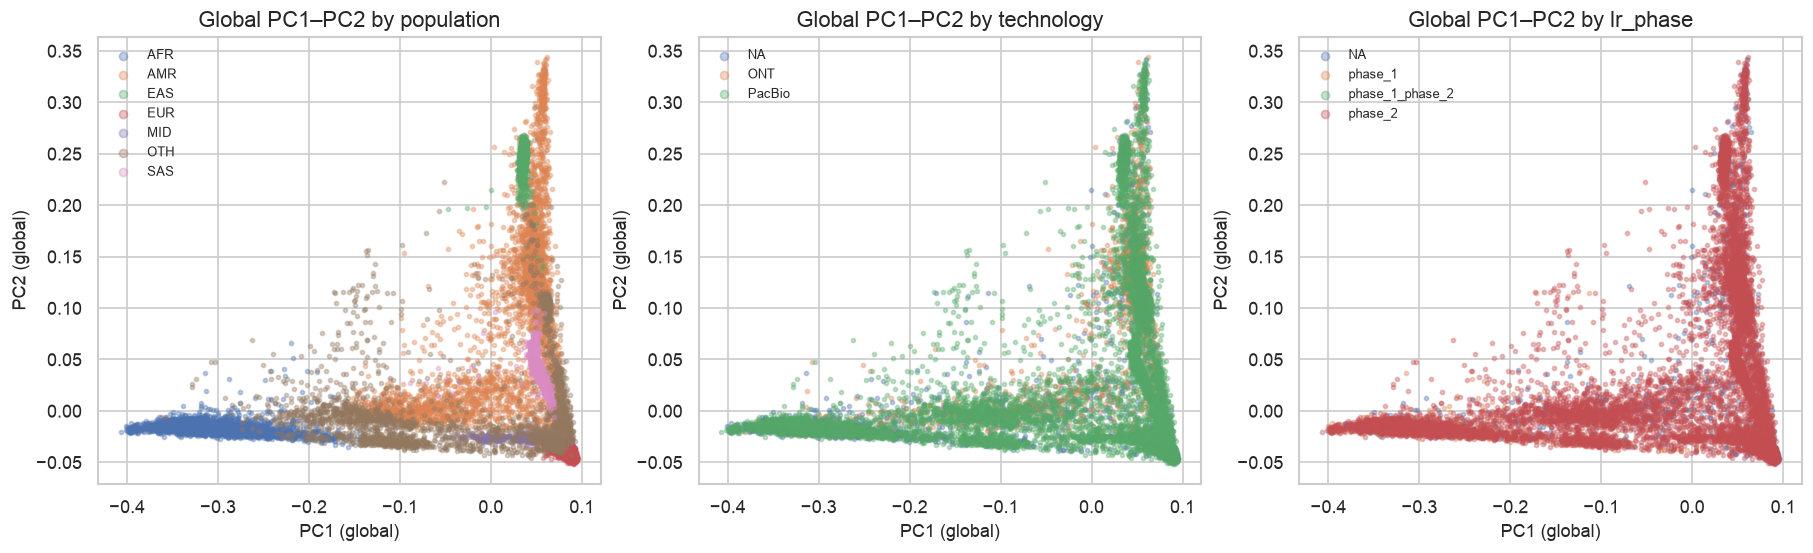

wrote summaries/figures/population_counts.png


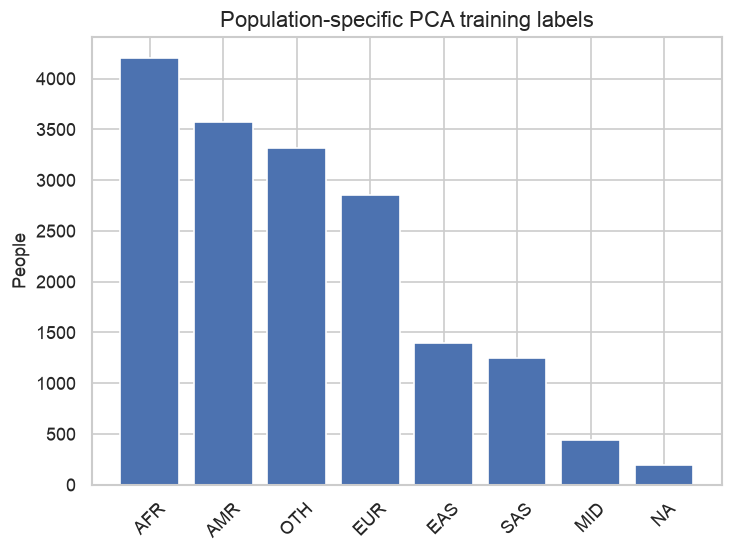

wrote summaries/figures/population_specific_pc_panels.png


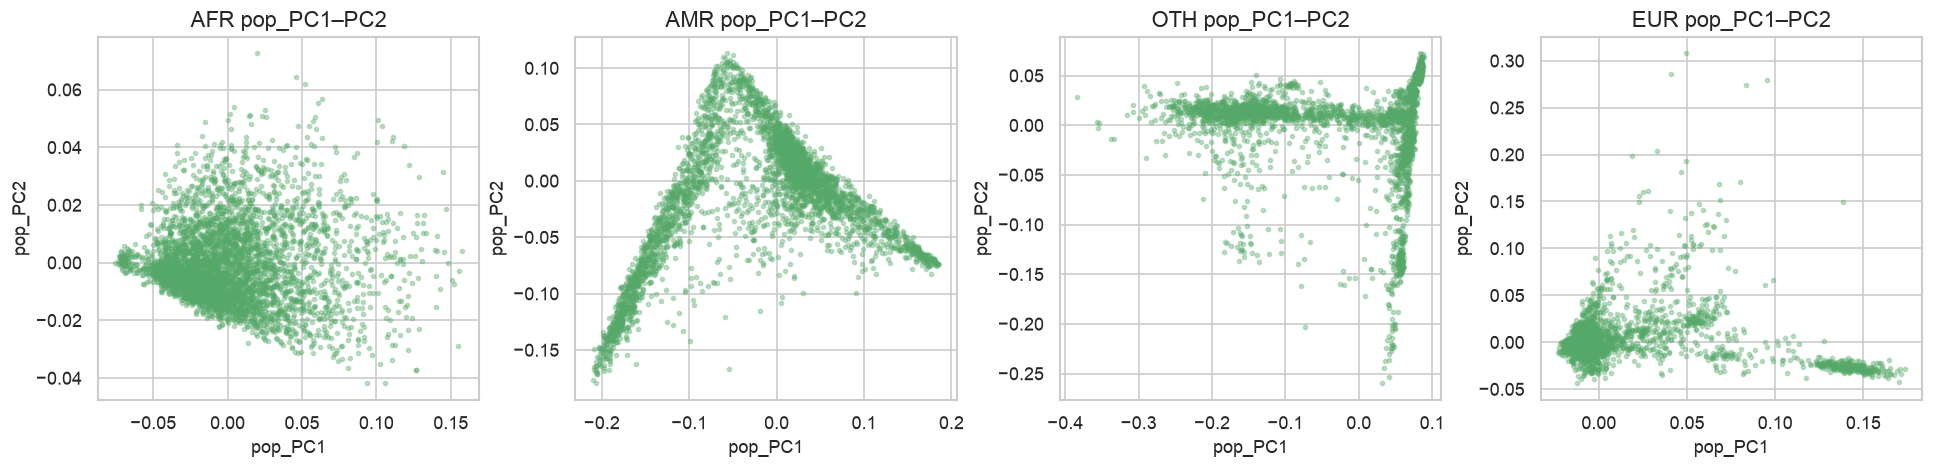

In [9]:
pop_tab = value_counts_table(df["population"], "population")

display(pop_tab)

save_table(pop_tab, "population_counts", manuscript=True)



pca_avail = pd.DataFrame([

    {"metric": "has_global_pcs", **count_flag(df["has_global_pcs"])},

    {"metric": "has_pop_pcs", **count_flag(df["has_pop_pcs"])},

])

display(pca_avail)

save_table(pca_avail, "pca_availability", manuscript=True)



pca = df.loc[df["has_global_pcs"], ["research_id", "PC1", "PC2", "PC3", "population", "technology", "lr_phase"]].copy()

pca["population"] = pca["population"].fillna("NA")

pca["technology"] = pca["technology"].fillna("NA")

pca["lr_phase"] = pca["lr_phase"].fillna("NA")



fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

for ax, color_col, title in [

    (axes[0], "population", "Global PC1–PC2 by population"),

    (axes[1], "technology", "Global PC1–PC2 by technology"),

    (axes[2], "lr_phase", "Global PC1–PC2 by lr_phase"),

]:

    for key, sub in pca.groupby(color_col):

        ax.scatter(sub["PC1"], sub["PC2"], s=6, alpha=0.35, label=str(key))

    ax.set_xlabel("PC1 (global)")

    ax.set_ylabel("PC2 (global)")

    ax.set_title(title)

    ax.legend(markerscale=2, frameon=False, fontsize=8, loc="best")

save_fig(fig, "global_pc1_pc2_colored")

plt.show()

plt.close('all')



fig, ax = plt.subplots(figsize=(6, 4.5), constrained_layout=True)

ax.bar(pop_tab["population"].astype(str), pop_tab["n"], color="#4C72B0")

ax.set_ylabel("People")

ax.set_title("Population-specific PCA training labels")

ax.tick_params(axis="x", rotation=45)

save_fig(fig, "population_counts")

plt.show()

plt.close('all')



# Within-population PC1–PC2 for largest populations (separate panels; same pop_PC space only within pop)

top_pops = [p for p in pop_tab["population"].tolist() if p != "NA"][:4]

fig, axes = plt.subplots(1, len(top_pops), figsize=(4 * len(top_pops), 3.8), constrained_layout=True)

if len(top_pops) == 1:

    axes = [axes]

for ax, pop in zip(axes, top_pops):

    sub = df.loc[(df["population"] == pop) & df["has_pop_pcs"], ["pop_PC1", "pop_PC2"]]

    ax.scatter(sub["pop_PC1"], sub["pop_PC2"], s=6, alpha=0.35, color="#55A868")

    ax.set_title(f"{pop} pop_PC1–PC2")

    ax.set_xlabel("pop_PC1")

    ax.set_ylabel("pop_PC2")

save_fig(fig, "population_specific_pc_panels")

plt.show()

plt.close('all')



## 5. External ancestry and pedigree annotations

`ancestry_pred` and `ancestry_pred_other` are retained exactly from the supplied
external annotation export; they are descriptive labels, not replacements for the
full-training PCs used in association adjustment. The pedigree contributes
family-level relatedness metadata. To minimize disclosure, parent IDs are not
exported in the rebuilt person-level table.


In [ ]:
ancestry_cols = ["ancestry_pred", "ancestry_pred_other"]
ancestry_tables = []
for column in ancestry_cols:
    tab = value_counts_table(df.loc[df["has_ancestry_annotation"], column], column)
    tab = tab.rename(columns={column: "label"})
    tab.insert(0, "annotation", column)
    ancestry_tables.append(tab)
ancestry_summary = pd.concat(ancestry_tables, ignore_index=True)
save_table(ancestry_summary, "external_ancestry_annotation_counts", manuscript=True)
display(ancestry_summary)

pedigree_people = df.loc[df["in_pedigree"]].copy()
pedigree_summary = pd.DataFrame([
    {
        "n_people": len(pedigree_people),
        "n_families": int(pedigree_people["pedigree_family_id"].nunique()),
        "n_founders": int(pedigree_people["pedigree_is_founder"].sum()),
        "n_nonfounders": int((~pedigree_people["pedigree_is_founder"]).sum()),
        "median_family_size": float(pedigree_people["pedigree_family_size"].median()),
        "max_family_size": int(pedigree_people["pedigree_family_size"].max()),
    }
])
save_table(pedigree_summary, "pedigree_summary", manuscript=True)
display(pedigree_summary)

pedigree_family_sizes = (
    pedigree_people[["pedigree_family_id", "pedigree_family_size"]]
    .drop_duplicates()
    .sort_values("pedigree_family_size", ascending=False)
)
save_table(pedigree_family_sizes, "pedigree_family_sizes")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for ax, column, title in [
    (axes[0], "ancestry_pred", "External ancestry prediction"),
    (axes[1], "ancestry_pred_other", "External prediction (with oth)"),
]:
    tab = value_counts_table(df.loc[df["has_ancestry_annotation"], column], column)
    ax.bar(tab[column].astype(str), tab["n"], color="#4C78A8")
    ax.set_title(title)
    ax.set_xlabel("Label")
    ax.set_ylabel("People")
    ax.tick_params(axis="x", rotation=35)
fig.suptitle("External ancestry annotation coverage and labels")
save_fig(fig, "external_ancestry_annotations")
plt.show()
plt.close('all')

print(
    f"External ancestry annotations: {int(df['has_ancestry_annotation'].sum()):,}/{N:,}; "
    f"pedigree: {len(pedigree_people):,} people in "
    f"{int(pedigree_people['pedigree_family_id'].nunique()):,} families."
)


## 6. Overlaps and joint availability

Pairwise co-occurrence counts / Jaccard for key boolean availability flags, plus
a binary presence heatmap over a random subsample for visual inspection.


,has_lr_tech,final_releasable_v9,has_methylation,has_srWGS,has_rna,has_proteomics,has_exposomics,has_trgt,in_phenotype_table,has_global_pcs,withdrawn
has_lr_tech,13530,13530,13530,13507,8327,9243,3510,12266,9854,13507,0
final_releasable_v9,13530,13530,13530,13507,8327,9243,3510,12266,9854,13507,0
has_methylation,13530,13530,13662,13639,8327,9243,3530,12392,9953,13507,123
has_srWGS,13507,13507,13639,17203,8979,9968,5635,12369,9944,17029,123
has_rna,8327,8327,8327,8979,8980,8801,3336,8327,6873,8979,0
has_proteomics,9243,9243,9243,9968,8801,9969,3646,9243,7544,9967,0
has_exposomics,3510,3510,3530,5635,3336,3646,5636,3519,3519,5600,17
has_trgt,12266,12266,12392,12369,8327,9243,3519,12392,9953,12243,117
in_phenotype_table,9854,9854,9953,9944,6873,7544,3519,9953,9953,9845,92
has_global_pcs,13507,13507,13507,17029,8979,9967,5600,12243,9845,17029,0


,has_lr_tech,final_releasable_v9,has_methylation,has_srWGS,has_rna,has_proteomics,has_exposomics,has_trgt,in_phenotype_table,has_global_pcs,withdrawn
has_lr_tech,1.000,1.000,0.990,0.784,0.587,0.648,0.224,0.898,0.723,0.792,0.000
final_releasable_v9,1.000,1.000,0.990,0.784,0.587,0.648,0.224,0.898,0.723,0.792,0.000
has_methylation,0.990,0.990,1.000,0.792,0.582,0.642,0.224,0.907,0.729,0.786,0.009
has_srWGS,0.784,0.784,0.792,1.000,0.522,0.579,0.328,0.718,0.578,0.990,0.007
has_rna,0.587,0.587,0.582,0.522,1.000,0.867,0.296,0.638,0.570,0.527,0.000
has_proteomics,0.648,0.648,0.642,0.579,0.867,1.000,0.305,0.705,0.609,0.585,0.000
has_exposomics,0.224,0.224,0.224,0.328,0.296,0.305,1.000,0.243,0.292,0.328,0.003
has_trgt,0.898,0.898,0.907,0.718,0.638,0.705,0.243,1.000,0.803,0.713,0.009
in_phenotype_table,0.723,0.723,0.729,0.578,0.570,0.609,0.292,0.803,1.000,0.574,0.009
has_global_pcs,0.792,0.792,0.786,0.990,0.527,0.585,0.328,0.713,0.574,1.000,0.000


wrote summaries/manuscript/flag_cooccurrence_counts_redacted.tsv (11 rows)
wrote summaries/manuscript/flag_jaccard.tsv (11 rows)
wrote summaries/figures/flag_overlap_heatmaps.png


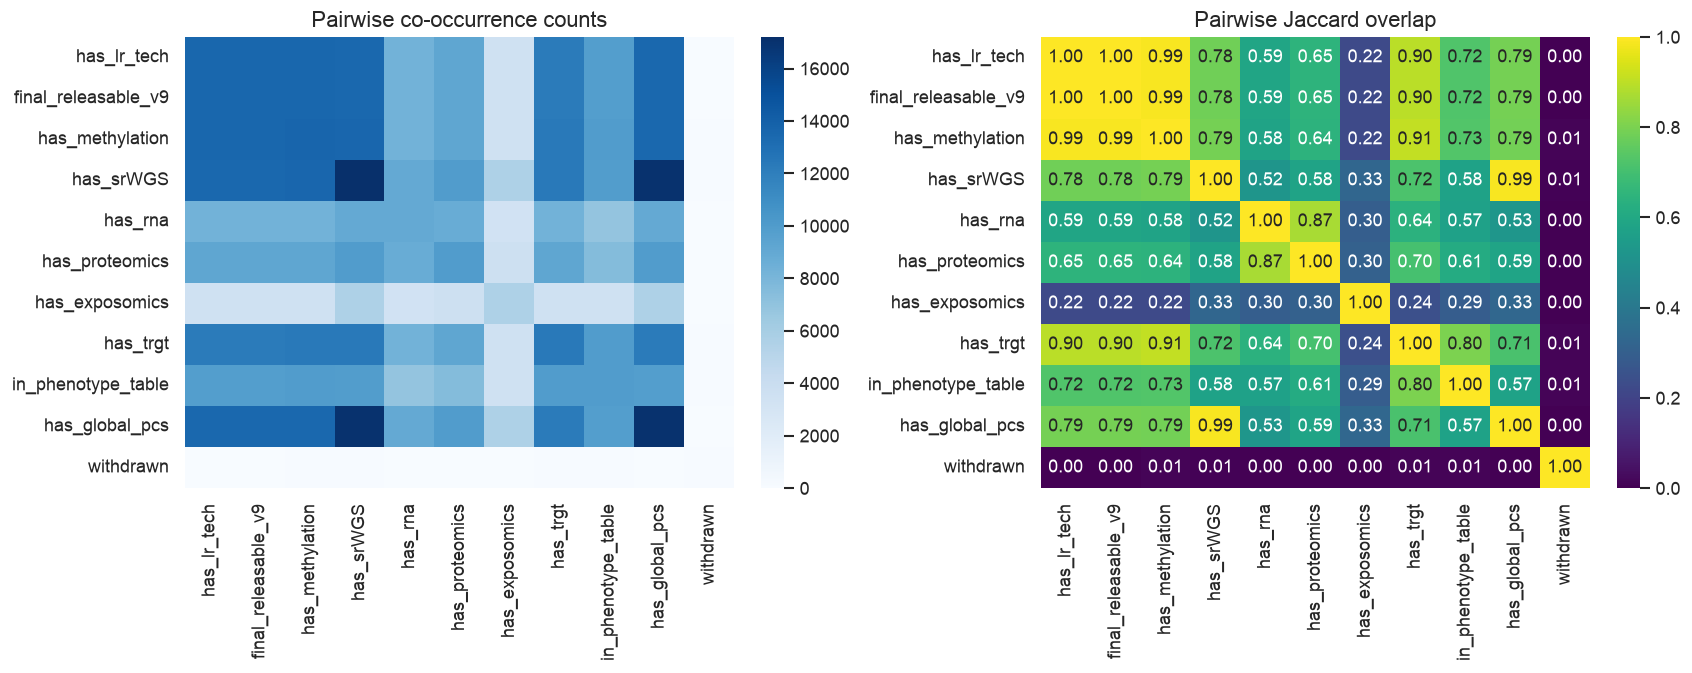

,pattern_bits,n,pattern
0,11111,6716,has_methylation + has_rna + has_proteomics + i...
1,00000,2834,(none)
2,10011,2252,has_methylation + in_phenotype_table + has_trgt
3,11101,1436,has_methylation + has_rna + has_proteomics + h...
4,10000,1270,has_methylation
5,10111,828,has_methylation + has_proteomics + in_phenotyp...
6,10001,722,has_methylation + has_trgt
7,01100,649,has_rna + has_proteomics
8,10101,263,has_methylation + has_proteomics + has_trgt
9,11011,157,has_methylation + has_rna + in_phenotype_table...


wrote summaries/tables/modality_intersection_top20_redacted.tsv (13 rows)
wrote summaries/figures/modality_intersection_bars.png


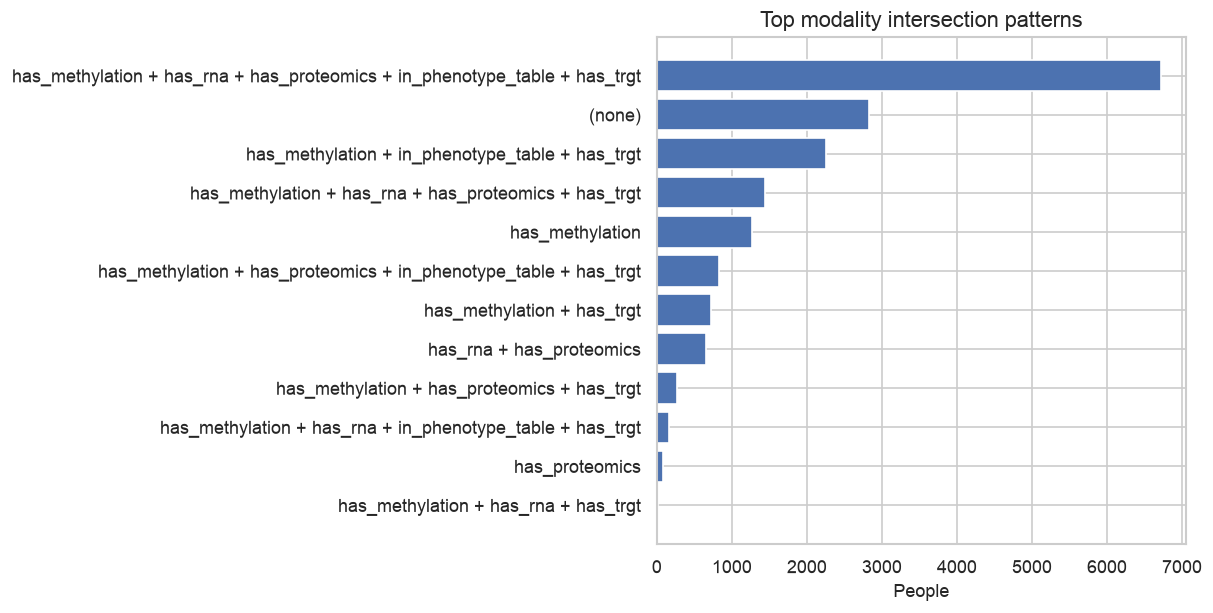

In [10]:
overlap_flags = [

    "has_lr_tech", "final_releasable_v9", "has_methylation", "has_srWGS",

    "has_rna", "has_proteomics", "has_exposomics", "has_trgt",

    "in_phenotype_table", "has_global_pcs", "withdrawn",

]



mat = df[overlap_flags].fillna(False).astype(bool)

n = len(mat)

cooccur = pd.DataFrame(index=overlap_flags, columns=overlap_flags, dtype=float)

jaccard = pd.DataFrame(index=overlap_flags, columns=overlap_flags, dtype=float)

for a in overlap_flags:

    for b in overlap_flags:

        both = int((mat[a] & mat[b]).sum())

        union = int((mat[a] | mat[b]).sum())

        cooccur.loc[a, b] = both

        jaccard.loc[a, b] = both / union if union else np.nan



cooccur_out = cooccur.reset_index(names="flag")

jaccard_out = jaccard.reset_index(names="flag")

display(cooccur.astype(int))

display(jaccard.round(3))

save_table(redact_small(cooccur_out), "flag_cooccurrence_counts_redacted", manuscript=True)

save_table(jaccard_out, "flag_jaccard", manuscript=True)



fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

sns.heatmap(cooccur.astype(float), annot=False, cmap="Blues", ax=axes[0])

axes[0].set_title("Pairwise co-occurrence counts")

sns.heatmap(jaccard.astype(float), annot=True, fmt=".2f", cmap="viridis", ax=axes[1], vmin=0, vmax=1)

axes[1].set_title("Pairwise Jaccard overlap")

save_fig(fig, "flag_overlap_heatmaps")

plt.show()

plt.close('all')



# Upset-like bar of intersection sizes for a focused modality set

focus = ["has_methylation", "has_rna", "has_proteomics", "in_phenotype_table", "has_trgt"]

key = mat[focus].astype(int).astype(str).agg("".join, axis=1)

inter_counts = key.value_counts().head(20).rename_axis("pattern_bits").reset_index(name="n")

# human-readable pattern

def bits_to_label(bits: str) -> str:

    on = [f for f, b in zip(focus, bits) if b == "1"]

    return " + ".join(on) if on else "(none)"

inter_counts["pattern"] = inter_counts["pattern_bits"].map(bits_to_label)

display(inter_counts)

save_table(redact_small(inter_counts.drop(columns=["pattern_bits"])), "modality_intersection_top20_redacted")



fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

plot_df = inter_counts.head(12).iloc[::-1]

ax.barh(plot_df["pattern"], plot_df["n"], color="#4C72B0")

ax.set_xlabel("People")

ax.set_title("Top modality intersection patterns")

save_fig(fig, "modality_intersection_bars")

plt.show()

plt.close('all')



## 7. Manuscript-ready compact tables

Denominators are the full multiomics universe unless noted.


In [11]:
ms_cohort = cohort_summary.copy()

ms_modality = modality_summary.copy()

ms_demo = pd.concat([

    age_stats.assign(table="age_stats"),

    sex_tab.assign(table="sex_at_birth"),

    zip3_complete.assign(table="zip3_completeness"),

], ignore_index=True)

ms_tech = pd.concat([

    cov_stats.assign(table="coverage"),

    gc_tab.assign(table="GC"),

    ext_tab.assign(table="extraction_method"),

    tech_tab.assign(table="technology"),

], ignore_index=True)

ms_pop = pop_tab.copy()



save_table(ms_cohort, "ms_cohort_summary", manuscript=True)

save_table(ms_modality, "ms_modality_availability", manuscript=True)

save_table(ms_demo, "ms_demographics_bundle", manuscript=True)

save_table(ms_tech, "ms_technical_bundle", manuscript=True)

save_table(ms_pop, "ms_population_counts", manuscript=True)



# Analysis-ready completeness among non-withdrawn people with LR tech

ready = df.loc[~df["withdrawn"] & df["has_lr_tech"]].copy()

ready_checks = pd.DataFrame([

    {"field": "age", "n": int(ready["age"].notna().sum()), "frac": float(ready["age"].notna().mean()), "meaning": "non_missing"},

    {"field": "sex_at_birth", "n": int(ready["sex_at_birth"].notna().sum()), "frac": float(ready["sex_at_birth"].notna().mean()), "meaning": "non_missing"},

    {"field": "PC1", "n": int(ready["PC1"].notna().sum()), "frac": float(ready["PC1"].notna().mean()), "meaning": "non_missing"},

    {"field": "coverage", "n": int(ready["coverage"].notna().sum()), "frac": float(ready["coverage"].notna().mean()), "meaning": "non_missing"},

    {"field": "GC", "n": int(ready["GC"].notna().sum()), "frac": float(ready["GC"].notna().mean()), "meaning": "non_missing"},

    {"field": "extraction_method", "n": int(ready["extraction_method"].notna().sum()), "frac": float(ready["extraction_method"].notna().mean()), "meaning": "non_missing"},

    {"field": "in_phenotype_table", "n": int(ready["in_phenotype_table"].sum()), "frac": float(ready["in_phenotype_table"].mean()), "meaning": "flag_true"},

])

ready_checks.insert(0, "denominator", len(ready))

display(ready_checks)

save_table(ready_checks, "analysis_field_completeness_lr_tech_not_withdrawn", manuscript=True)



wrote summaries/manuscript/ms_cohort_summary.tsv (13 rows)
wrote summaries/manuscript/ms_modality_availability.tsv (8 rows)
wrote summaries/manuscript/ms_demographics_bundle.tsv (18 rows)
wrote summaries/manuscript/ms_technical_bundle.tsv (22 rows)
wrote summaries/manuscript/ms_population_counts.tsv (8 rows)


,denominator,field,n,frac,meaning
0,13530,age,13527,0.999778,non_missing
1,13530,sex_at_birth,13527,0.999778,non_missing
2,13530,PC1,13507,0.998300,non_missing
3,13530,coverage,13530,1.000000,non_missing
4,13530,GC,13530,1.000000,non_missing
5,13530,extraction_method,13530,1.000000,non_missing
6,13530,in_phenotype_table,9854,0.728307,flag_true


wrote summaries/manuscript/analysis_field_completeness_lr_tech_not_withdrawn.tsv (7 rows)


PosixPath('/Users/kiran/repositories/aou-lr-phase-2/tractor_mix/summaries/manuscript/analysis_field_completeness_lr_tech_not_withdrawn.tsv')

## 8. Covariate-justification diagnostics

This section evaluates prospective technical covariates against the **limited**
model (age, sex at birth, global PC1–PC10). It reports:

1. sample loss from requiring each candidate;
2. multicollinearity in an expanded technical design; and
3. likelihood-ratio tests (LRTs) on an automatically selected, prevalence-stratified
   panel of eligible binary phenotypes.

The automated phenotype panel is a calibration screen—not a clinical endpoint
analysis. It selects 12 de-identified 0/1 columns with at least 100 cases and
100 controls, spaced across observed prevalence. Results should be confirmed on
pre-specified traits before finalizing a model.

,candidate,base_complete_n,candidate_complete_n,n_lost,frac_lost
2,extraction_method,17024,14494,2530,0.148614
5,lr_phase,17024,14494,2530,0.148614
1,GC,17024,13504,3520,0.206767
0,coverage,17024,13504,3520,0.206767
4,platform,17024,13504,3520,0.206767
3,technology,17024,13504,3520,0.206767
6,pb_meth_caller,17024,12235,4789,0.281309


wrote summaries/manuscript/covariate_candidate_missingness_cost.tsv (7 rows)


/Users/kiran/repositories/aou-lr-phase-2/venv/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,shared_complete_n,n_design_terms,max_vif,n_terms_vif_gt_5,n_terms_vif_gt_10
0,12235,25,inf,8,6


,term,VIF
24,pb_meth_caller_primrose-1.2.0,inf
21,platform_Sequel,inf
22,lr_phase_phase_2,117.325344
17,GC_BI,32.195634
16,coverage,25.502571
0,age,11.587719
20,extraction_method_Chemagen,5.862334
18,GC_HA,5.442086
2,PC2,2.331511
3,PC3,1.990937


...

,candidate,n_traits,n_nominal_signal,median_delta_AIC,median_lrt_p,median_n
0,GC,11,6,2.006454,0.045879,9621.0
1,coverage,11,4,-0.262548,0.187462,9621.0
4,pb_meth_caller,11,3,-2.290603,0.221927,9621.0
3,lr_phase,11,1,-1.356434,0.422423,9621.0
2,extraction_method,11,1,-1.803122,0.657253,9621.0
6,technology,11,1,-1.889079,0.739098,9621.0
5,platform,11,1,-2.985467,0.602139,9621.0


,phenotype,candidate,n,cases,candidate_df,delta_deviance,lrt_p,delta_AIC,lrt_q_bh
71,CV_401,GC,9271,3038,3,36.986209,4.632397e-08,30.986209,0.000004
43,CV_440.1,GC,9621,328,3,23.355474,3.404735e-05,17.355474,0.001311
64,SO_371,GC,9490,956,3,20.440919,1.375215e-04,14.440919,0.003530
15,SO_374.42,GC,9782,153,3,12.101172,7.044502e-03,6.101172,0.077490
50,SO_390,GC,9414,430,3,9.736816,2.094102e-02,3.736816,0.134372
57,SO_396,GC,9484,629,3,8.006454,4.587852e-02,2.006454,0.207803
22,CV_423,GC,9675,180,3,7.804012,5.024070e-02,1.804012,0.214919
29,RE_483,GC,9659,213,3,6.787594,7.898501e-02,0.787594,0.289612
8,PP_928,GC,9736,133,3,6.498844,8.970809e-02,0.498844,0.313978
1,SO_377,GC,9702,116,3,4.737273,1.920776e-01,-1.262727,0.568845


wrote summaries/tables/covariate_candidate_binary_trait_lrt.tsv (77 rows)
wrote summaries/manuscript/covariate_candidate_binary_trait_lrt_summary.tsv (7 rows)


,candidate,screen_assessment,rationale,frac_lost,n_nominal_signal,median_delta_AIC
0,coverage,retain_core,continuous sequencing-depth covariate; modest ...,0.206767,4,-0.262548
1,GC,retain_core,strongest phenotype-screen signal (6/11 traits...,0.206767,6,2.006454
2,extraction_method,sensitivity_test,little binary-trait-screen support (1/11); add...,0.148614,1,-1.803122
3,technology,do_not_add_with_platform_or_caller,little screen support; overlaps structurally w...,0.206767,1,-1.889079
4,platform,do_not_add_with_technology_or_caller,little screen support; exact collinearity with...,0.206767,1,-2.985467
5,lr_phase,sensitivity_test,little screen support; phase may still be eval...,0.148614,1,-1.356434
6,pb_meth_caller,do_not_add_with_platform,28.1% limited-cohort loss; exact collinearity ...,0.281309,3,-2.290603


wrote summaries/manuscript/covariate_candidate_decision_aid.tsv (7 rows)
wrote summaries/figures/covariate_justification_screen.png


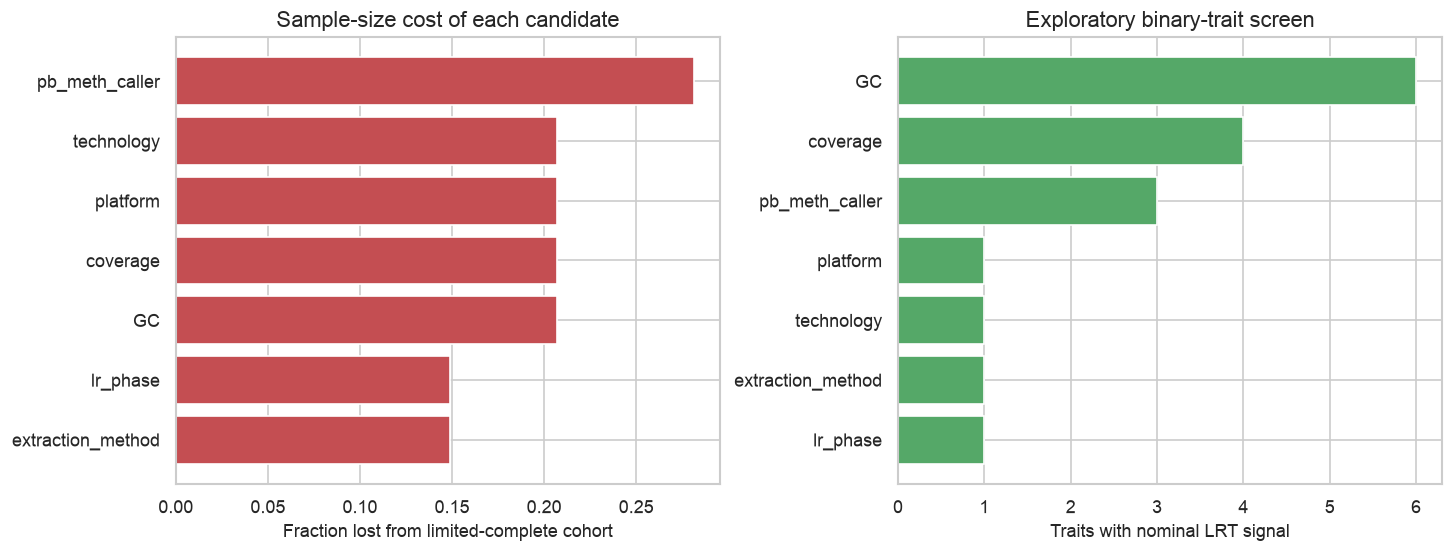

In [12]:
import statsmodels.api as sm



from scipy.stats import chi2



from statsmodels.stats.outliers_influence import variance_inflation_factor







# Candidate terms are assessed as blocks: continuous coverage or a complete set



# of treatment-coded categorical dummies. Do not include modality/status flags.



CANDIDATES = {



    "coverage": "continuous",



    "GC": "categorical",



    "extraction_method": "categorical",



    "technology": "categorical",



    "platform": "categorical",



    "lr_phase": "categorical",



    "pb_meth_caller": "categorical",



}



BASE_COLS = ["age", "sex_at_birth", *[f"PC{i}" for i in range(1, 11)]]











def design_matrix(frame: pd.DataFrame, *, candidate: str | None = None) -> pd.DataFrame:



    """Limited model plus an optional technical-covariate block."""



    base = frame[BASE_COLS].copy()



    base["age"] = pd.to_numeric(base["age"], errors="coerce")



    base = pd.concat(



        [base.drop(columns=["sex_at_birth"]),



         pd.get_dummies(base["sex_at_birth"].fillna("NA"), prefix="sex", drop_first=True, dtype=float)],



        axis=1,



    )



    if candidate is not None:



        if CANDIDATES[candidate] == "continuous":



            base[candidate] = pd.to_numeric(frame[candidate], errors="coerce")



        else:



            dummies = pd.get_dummies(



                frame[candidate].fillna("NA"), prefix=candidate, drop_first=True, dtype=float



            )



            base = pd.concat([base, dummies], axis=1)



    return sm.add_constant(base, has_constant="add").astype(float)











# Missingness cost: base-complete cohort versus each candidate-complete cohort.



base_complete = df.dropna(subset=["age", *[f"PC{i}" for i in range(1, 11)]]).copy()



base_complete = base_complete.loc[base_complete["sex_at_birth"].notna() & ~base_complete["withdrawn"]]



cost_rows = []



for candidate in CANDIDATES:



    n_candidate = int(base_complete[candidate].notna().sum())



    cost_rows.append({



        "candidate": candidate,



        "base_complete_n": len(base_complete),



        "candidate_complete_n": n_candidate,



        "n_lost": len(base_complete) - n_candidate,



        "frac_lost": 1 - n_candidate / len(base_complete),



    })



missingness_cost = pd.DataFrame(cost_rows).sort_values(["frac_lost", "candidate"])



display(missingness_cost)



save_table(missingness_cost, "covariate_candidate_missingness_cost", manuscript=True)







# Collinearity: VIF in the shared all-candidate-complete cohort. This is a



# conservative diagnostic because the shared cohort can be smaller than any



# individual candidate-specific analysis cohort.



all_complete = base_complete.dropna(subset=list(CANDIDATES)).copy()



X_all = design_matrix(all_complete)



for candidate in CANDIDATES:



    block = design_matrix(all_complete, candidate=candidate).drop(



        columns=X_all.columns, errors="ignore"



    )



    X_all = pd.concat([X_all, block], axis=1)



keep = X_all.columns[X_all.nunique() > 1]



X_vif = X_all[keep]



vif = pd.DataFrame({



    "term": X_vif.columns,



    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],



}).query("term != 'const'").sort_values("VIF", ascending=False)



collinearity_summary = pd.DataFrame([{



    "shared_complete_n": len(all_complete),



    "n_design_terms": X_vif.shape[1] - 1,



    "max_vif": float(vif["VIF"].max()),



    "n_terms_vif_gt_5": int((vif["VIF"] > 5).sum()),



    "n_terms_vif_gt_10": int((vif["VIF"] > 10).sum()),



}])



display(collinearity_summary)



display(vif.head(30))



save_table(collinearity_summary, "covariate_collinearity_summary", manuscript=True)



save_table(vif, "covariate_term_vif")







# Profile the wide phenotype file without retaining its raw values. Only clean



# booleans are eligible, with at least 100 cases and 100 controls.



assert PHENOTYPE_CSV.exists(), PHENOTYPE_CSV



phen_stats: dict[str, dict[str, int]] = {}



for chunk in pd.read_csv(PHENOTYPE_CSV, chunksize=1000, low_memory=False):



    for column in chunk.columns:



        if column in {"person_id", "Unnamed: 0"}:



            continue



        values = chunk[column].dropna().astype(str).str.lower()



        if values.empty or not values.isin({"true", "false"}).all():



            continue



        stats = phen_stats.setdefault(column, {"n": 0, "cases": 0})



        stats["n"] += len(values)



        stats["cases"] += int((values == "true").sum())







phen_profile = pd.DataFrame([



    {"phenotype": column, **stats, "controls": stats["n"] - stats["cases"],



     "prevalence": stats["cases"] / stats["n"]}



    for column, stats in phen_stats.items()



])



eligible = phen_profile.query("cases >= 100 and controls >= 100").sort_values("prevalence").reset_index(drop=True)



assert len(eligible) >= 12, "fewer than 12 eligible binary phenotype columns"



# Deterministic spread across the prevalence distribution; do not hand-pick traits.



panel_index = np.linspace(0, len(eligible) - 1, 12, dtype=int)



trait_panel = eligible.iloc[panel_index].drop_duplicates("phenotype").reset_index(drop=True)



display(trait_panel)



save_table(trait_panel, "auto_binary_phenotype_panel")







phen = pd.read_csv(



    PHENOTYPE_CSV,



    usecols=["person_id", *trait_panel["phenotype"].tolist()],



    dtype={"person_id": str},



    low_memory=False,



).rename(columns={"person_id": "research_id"})



phen["research_id"] = phen["research_id"].astype(str)



model_data = df.merge(phen, on="research_id", how="inner", validate="one_to_one")







# LRT: compare limited to limited + candidate on identical rows per trait/candidate.



lrt_rows = []



for trait in trait_panel["phenotype"]:



    y_all = model_data[trait].map({True: 1, False: 0, "True": 1, "False": 0}).astype(float)



    for candidate in CANDIDATES:



        X_full = design_matrix(model_data, candidate=candidate)



        valid = y_all.notna() & X_full.notna().all(axis=1)



        y = y_all.loc[valid]



        if y.nunique() != 2 or y.sum() < 100 or (len(y) - y.sum()) < 100:



            continue



        X0 = design_matrix(model_data.loc[valid])



        X1 = X_full.loc[valid]



        try:



            m0 = sm.GLM(y, X0, family=sm.families.Binomial()).fit(maxiter=100, disp=0)



            m1 = sm.GLM(y, X1, family=sm.families.Binomial()).fit(maxiter=100, disp=0)



            lrt = max(0.0, 2 * (m1.llf - m0.llf))



            df_diff = int(m1.df_model - m0.df_model)



            p = chi2.sf(lrt, df_diff) if df_diff > 0 else np.nan



            lrt_rows.append({



                "phenotype": trait, "candidate": candidate, "n": int(len(y)),



                "cases": int(y.sum()), "candidate_df": df_diff,



                "delta_deviance": lrt, "lrt_p": p,



                "delta_AIC": float(m0.aic - m1.aic),



            })



        except (np.linalg.LinAlgError, ValueError):



            lrt_rows.append({



                "phenotype": trait, "candidate": candidate, "n": int(len(y)),



                "cases": int(y.sum()), "candidate_df": np.nan,



                "delta_deviance": np.nan, "lrt_p": np.nan, "delta_AIC": np.nan,



            })







lrt = pd.DataFrame(lrt_rows)



assert not lrt.empty



# Benjamini–Hochberg FDR within this exploratory panel.



lrt["lrt_q_bh"] = np.nan



valid_p = lrt["lrt_p"].notna()



ranked = lrt.loc[valid_p, "lrt_p"].rank(method="first")



lrt.loc[valid_p, "lrt_q_bh"] = np.minimum(1, lrt.loc[valid_p, "lrt_p"] * valid_p.sum() / ranked)



lrt["lrt_q_bh"] = lrt.groupby("candidate")["lrt_q_bh"].transform(lambda x: np.minimum.accumulate(x.sort_values(ascending=False)).reindex(x.index))



# The primary selection summary uses nominal p<0.05 and ΔAIC>2; interpret as screening only.



lrt_summary = (



    lrt.assign(nominal_signal=(lrt["lrt_p"] < 0.05) & (lrt["delta_AIC"] > 2))



    .groupby("candidate", as_index=False)



    .agg(



        n_traits=("phenotype", "nunique"),



        n_nominal_signal=("nominal_signal", "sum"),



        median_delta_AIC=("delta_AIC", "median"),



        median_lrt_p=("lrt_p", "median"),



        median_n=("n", "median"),



    )



    .sort_values(["n_nominal_signal", "median_delta_AIC"], ascending=False)



)



display(lrt_summary)



display(lrt.sort_values(["candidate", "lrt_p"]).head(40))



save_table(lrt, "covariate_candidate_binary_trait_lrt")



save_table(lrt_summary, "covariate_candidate_binary_trait_lrt_summary", manuscript=True)







# Decision aid, not an automated model-selection rule. Interpret alongside null-model



# calibration from the matched Tractor-Mix / SAIGE pilot.



recommendations = pd.DataFrame([



    {



        "candidate": "coverage",



        "screen_assessment": "retain_core",



        "rationale": "continuous sequencing-depth covariate; modest trait-screen signal; 20.7% limited-cohort loss",



    },



    {



        "candidate": "GC",



        "screen_assessment": "retain_core",



        "rationale": "strongest phenotype-screen signal (6/11 traits); 20.7% limited-cohort loss",



    },



    {



        "candidate": "extraction_method",



        "screen_assessment": "sensitivity_test",



        "rationale": "little binary-trait-screen support (1/11); adds 14.9% limited-cohort loss",



    },



    {



        "candidate": "technology",



        "screen_assessment": "do_not_add_with_platform_or_caller",



        "rationale": "little screen support; overlaps structurally with platform and methylation caller",



    },



    {



        "candidate": "platform",



        "screen_assessment": "do_not_add_with_technology_or_caller",



        "rationale": "little screen support; exact collinearity with a methylation-caller level in shared design",



    },



    {



        "candidate": "lr_phase",



        "screen_assessment": "sensitivity_test",



        "rationale": "little screen support; phase may still be evaluated if pilot QQ plots show batch structure",



    },



    {



        "candidate": "pb_meth_caller",



        "screen_assessment": "do_not_add_with_platform",



        "rationale": "28.1% limited-cohort loss; exact collinearity with platform in shared design",



    },



]).merge(



    missingness_cost[["candidate", "frac_lost"]], on="candidate", how="left"



).merge(



    lrt_summary[["candidate", "n_nominal_signal", "median_delta_AIC"]], on="candidate", how="left"



)



display(recommendations)



save_table(recommendations, "covariate_candidate_decision_aid", manuscript=True)







fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)



plot_cost = missingness_cost.sort_values("frac_lost")



axes[0].barh(plot_cost["candidate"], plot_cost["frac_lost"], color="#C44E52")



axes[0].set_xlabel("Fraction lost from limited-complete cohort")



axes[0].set_title("Sample-size cost of each candidate")



plot_lrt = lrt_summary.sort_values("n_nominal_signal")



axes[1].barh(plot_lrt["candidate"], plot_lrt["n_nominal_signal"], color="#55A868")



axes[1].set_xlabel("Traits with nominal LRT signal")



axes[1].set_title("Exploratory binary-trait screen")



save_fig(fig, "covariate_justification_screen")



plt.show()



plt.close("all")



# Working-group slide: per-trait evidence that coverage / GC improve the



# limited phenotype null more often than weaker technical candidates.



focus = ["coverage", "GC", "extraction_method"]



sub = lrt.loc[lrt["candidate"].isin(focus)].copy()



order = (



    sub.loc[sub["candidate"].eq("coverage")]



    .sort_values("cases")["phenotype"]



    .tolist()



)



sub["phenotype"] = pd.Categorical(sub["phenotype"], categories=order, ordered=True)







fig, axes = plt.subplots(



    1, 3, figsize=(14.5, 5.2), constrained_layout=True,



    gridspec_kw={"width_ratios": [1.1, 1.35, 1.35]},



)



bar = lrt_summary.merge(missingness_cost[["candidate", "frac_lost"]], on="candidate", how="left")



bar = bar.loc[bar["candidate"].isin(["coverage", "GC", "extraction_method", "platform", "technology"])].copy()



bar = bar.sort_values("n_nominal_signal")



axes[0].barh(bar["candidate"], bar["n_nominal_signal"], color="#55A868")



axes[0].set_xlabel("Traits with nominal LRT signal")



axes[0].set_title("A. Screen summary\n(limited → + candidate)")



for y, (_, row) in enumerate(bar.iterrows()):



    axes[0].text(



        row["n_nominal_signal"] + 0.08, y,



        f"loss {100 * row['frac_lost']:.0f}%",



        va="center", fontsize=9, color="0.35",



    )



axes[0].set_xlim(0, max(6.8, float(bar["n_nominal_signal"].max()) + 1.5))







for ax, candidate, title, color in [



    (axes[1], "coverage", "B. Adding coverage", "#4C72B0"),



    (axes[2], "GC", "C. Adding genome center (GC)", "#8172B3"),



]:



    s = sub.loc[sub["candidate"].eq(candidate)].sort_values("phenotype")



    colors = [



        color if (p < 0.05 and d > 2) else "0.65"



        for p, d in zip(s["lrt_p"], s["delta_AIC"])



    ]



    ax.axvline(0, color="0.3", linestyle="--", linewidth=1)



    ax.scatter(s["delta_AIC"], s["phenotype"].astype(str), c=colors, s=55, zorder=3)



    for _, row in s.iterrows():



        ax.plot([0, row["delta_AIC"]], [str(row["phenotype"])] * 2, color="0.8", linewidth=1, zorder=1)



    ax.set_title(title)



    ax.set_xlabel("ΔAIC (limited → limited + term)")



    ax.set_ylabel("Auto-selected binary trait")



    ax.set_xlim(



        min(-6, float(s["delta_AIC"].min()) - 0.5),



        max(20, float(s["delta_AIC"].max()) + 0.5),



    )







fig.suptitle(



    "Covariate justification: after age, sex, and PC1–PC10,\n"



    f"coverage and GC improve the phenotype null more often than other technical terms "



    f"(n≈{int(sub['n'].median()):,}; colored points = nominal LRT signal)",



    fontsize=12,



)



save_fig(fig, "covariate_justification_wg_slide")



plt.show()



plt.close("all")



## 9. Association target: Phase 2 PacBio-only platform screen

The association-study cohort is restricted to non-withdrawn PacBio people with
`lr_phase` in `phase_2` or `phase_1_phase_2` (all are final-v9 releasable in
this rebuild). The LRT screen uses the subset also present in the phenotype
table. It compares **Sequel vs Revio** after the proposed core full adjustment:
age, sex at birth, global PC1–PC10, coverage, and GC.

`pb_meth_caller` is tested in a separate model only. It is deterministically
linked to platform for the Sequel rows (`primrose-1.2.0`), so it must not be
included with platform in the same model.

In [ ]:
PB_PHASES = ["phase_2", "phase_1_phase_2"]

pb_universe = df.loc[

    df["technology"].eq("PacBio")

    & df["lr_phase"].isin(PB_PHASES)

    & ~df["withdrawn"]

].copy()

pb = model_data.loc[

    model_data["technology"].eq("PacBio")

    & model_data["lr_phase"].isin(PB_PHASES)

    & ~model_data["withdrawn"]

].copy()

assert pb_universe["final_releasable_v9"].all()

assert pb["final_releasable_v9"].all()



pb_cohort = pd.DataFrame([{

    "cohort": "Phase 2 PacBio, not withdrawn",

    "n": len(pb_universe),

    "n_revio": int(pb_universe["platform"].eq("Revio").sum()),

    "n_sequel": int(pb_universe["platform"].eq("Sequel").sum()),

    "n_caller_mixed": int(pb_universe["pb_meth_caller"].eq("mixed").sum()),

}, {

    "cohort": "Phase 2 PacBio, phenotype-table subset used for LRT",

    "n": len(pb),

    "n_revio": int(pb["platform"].eq("Revio").sum()),

    "n_sequel": int(pb["platform"].eq("Sequel").sum()),

    "n_caller_mixed": int(pb["pb_meth_caller"].eq("mixed").sum()),

}])

display(pb_cohort)

save_table(pb_cohort, "pacbio_phase2_cohort", manuscript=True)



platform_caller = pd.crosstab(pb["platform"], pb["pb_meth_caller"], margins=True)

display(platform_caller)

save_table(platform_caller.reset_index(), "pacbio_platform_by_meth_caller")





def pb_core_design(frame: pd.DataFrame, candidate: str | None = None) -> pd.DataFrame:

    """Association-target core: limited covariates + coverage + GC."""

    x = frame[["age", "sex_at_birth", *[f"PC{i}" for i in range(1, 11)], "coverage", "GC"]].copy()

    x["age"] = pd.to_numeric(x["age"], errors="coerce")

    x["coverage"] = pd.to_numeric(x["coverage"], errors="coerce")

    x = pd.concat([

        x.drop(columns=["sex_at_birth", "GC"]),

        pd.get_dummies(x["sex_at_birth"].fillna("NA"), prefix="sex", drop_first=True, dtype=float),

        pd.get_dummies(x["GC"].fillna("NA"), prefix="GC", drop_first=True, dtype=float),

    ], axis=1)

    if candidate is not None:

        x = pd.concat([

            x,

            pd.get_dummies(frame[candidate].fillna("NA"), prefix=candidate, drop_first=True, dtype=float),

        ], axis=1)

    return sm.add_constant(x, has_constant="add").astype(float)





# Platform and methylation caller are alternative batch parameterizations, each

# tested against the same core covariates on identical rows per trait.

pb_lrt_rows = []

for trait in trait_panel["phenotype"]:

    y_all = pb[trait].map({True: 1, False: 0, "True": 1, "False": 0}).astype(float)

    for candidate in ["platform", "pb_meth_caller"]:

        X1 = pb_core_design(pb, candidate)

        valid = y_all.notna() & X1.notna().all(axis=1)

        y = y_all.loc[valid]

        if y.nunique() != 2 or y.sum() < 100 or (len(y) - y.sum()) < 100:

            continue

        X0 = pb_core_design(pb.loc[valid])

        X1 = X1.loc[valid]

        try:

            m0 = sm.GLM(y, X0, family=sm.families.Binomial()).fit(maxiter=100, disp=0)

            m1 = sm.GLM(y, X1, family=sm.families.Binomial()).fit(maxiter=100, disp=0)

            lrt_stat = max(0.0, 2 * (m1.llf - m0.llf))

            df_diff = int(m1.df_model - m0.df_model)

            pb_lrt_rows.append({

                "phenotype": trait, "candidate": candidate, "n": int(len(y)),

                "cases": int(y.sum()), "candidate_df": df_diff,

                "delta_deviance": lrt_stat,

                "lrt_p": chi2.sf(lrt_stat, df_diff) if df_diff > 0 else np.nan,

                "delta_AIC": float(m0.aic - m1.aic),

            })

        except (np.linalg.LinAlgError, ValueError):

            continue



pb_lrt = pd.DataFrame(pb_lrt_rows)

assert not pb_lrt.empty

pb_lrt_summary = (

    pb_lrt.assign(nominal_signal=(pb_lrt["lrt_p"] < 0.05) & (pb_lrt["delta_AIC"] > 2))

    .groupby("candidate", as_index=False)

    .agg(

        n_traits=("phenotype", "nunique"),

        n_nominal_signal=("nominal_signal", "sum"),

        median_delta_AIC=("delta_AIC", "median"),

        median_lrt_p=("lrt_p", "median"),

        median_n=("n", "median"),

    )

)

display(pb_lrt_summary)

display(pb_lrt.sort_values(["candidate", "lrt_p"]))

save_table(pb_lrt, "pacbio_phase2_platform_caller_lrt")

save_table(pb_lrt_summary, "pacbio_phase2_platform_caller_lrt_summary", manuscript=True)



# Instrument differences in coverage provide context; coverage itself remains a

# core covariate, so this does not imply adding platform to the final model.

pb_coverage = pb.groupby("platform", as_index=False)["coverage"].describe(percentiles=[0.25, 0.5, 0.75]).reset_index(drop=True)

display(pb_coverage)

save_table(pb_coverage, "pacbio_phase2_coverage_by_platform", manuscript=True)



# Compact diagnostic panel (retained for the atlas).

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

sns.boxplot(data=pb, x="platform", y="coverage", color="#64B5CD", ax=axes[0])

axes[0].set_title("PacBio Phase 2 coverage by instrument")

axes[0].set_xlabel("Platform")

axes[0].set_ylabel("Coverage")

plot = pb_lrt_summary.sort_values("candidate")

axes[1].bar(plot["candidate"], plot["n_nominal_signal"], color="#8172B3")

axes[1].set_title("Core + batch-term LRT screen")

axes[1].set_ylabel("Traits with nominal signal")

axes[1].set_xlabel("Additional batch term")

save_fig(fig, "pacbio_phase2_platform_caller_screen")

plt.show()

plt.close("all")



# Working-group slide: after age/sex/PCs/coverage/GC, does Sequel vs Revio

# (or methylation caller) improve the phenotype null?

pb_lrt_plot = pb_lrt.copy()

order = (

    pb_lrt_plot.loc[pb_lrt_plot["candidate"].eq("platform")]

    .sort_values("cases")["phenotype"]

    .tolist()

)

pb_lrt_plot["phenotype"] = pd.Categorical(pb_lrt_plot["phenotype"], categories=order, ordered=True)

pb_lrt_plot = pb_lrt_plot.sort_values(["candidate", "phenotype"])



fig, axes = plt.subplots(

    1, 3, figsize=(14.5, 5.2), constrained_layout=True,

    gridspec_kw={"width_ratios": [1.0, 1.35, 1.35]},

)



# A. Yields differ by instrument; median coverage is still in a similar range.

sns.boxplot(

    data=pb, x="platform", y="coverage", color="#4C72B0", ax=axes[0], showfliers=False,

)

sns.stripplot(

    data=pb.sample(n=min(1500, len(pb)), random_state=0),

    x="platform", y="coverage", color="0.35", size=1.5, alpha=0.25, ax=axes[0],

)

axes[0].set_title("A. Coverage by instrument")

axes[0].set_xlabel("")

axes[0].set_ylabel("Mean coverage")



# B/C. Per-trait ΔAIC for adding platform or caller to the core model.

# Positive ΔAIC favors including the term; the dashed line is no improvement.

for ax, candidate, title, color in [

    (axes[1], "platform", "B. Adding Sequel vs Revio", "#55A868"),

    (axes[2], "pb_meth_caller", "C. Adding methylation caller", "#C44E52"),

]:

    sub = pb_lrt_plot.loc[pb_lrt_plot["candidate"].eq(candidate)].copy()

    colors = [

        color if (p < 0.05 and d > 2) else "0.65"

        for p, d in zip(sub["lrt_p"], sub["delta_AIC"])

    ]

    ax.axvline(0, color="0.3", linestyle="--", linewidth=1)

    ax.scatter(sub["delta_AIC"], sub["phenotype"].astype(str), c=colors, s=55, zorder=3)

    for _, row in sub.iterrows():

        ax.plot(

            [0, row["delta_AIC"]], [str(row["phenotype"])] * 2,

            color="0.8", linewidth=1, zorder=1,

        )

    ax.set_title(title)

    ax.set_xlabel("ΔAIC (core → core + term)")

    ax.set_ylabel("Auto-selected binary trait")

    ax.set_xlim(

        min(-6, float(sub["delta_AIC"].min()) - 0.5),

        max(12, float(sub["delta_AIC"].max()) + 0.5),

    )



fig.suptitle(

    "Phase 2 PacBio association cohort: after age, sex, PC1–PC10, coverage, and GC,\n"

    "instrument / methylation-caller terms rarely improve the phenotype null "

    f"(n={len(pb):,}; colored points = nominal LRT signal)",

    fontsize=12,

)

save_fig(fig, "pacbio_phase2_wg_slide")

plt.show()

plt.close("all")



## 10. Are SV counts useful association covariates?

Unified per-sample INS/DEL counts are useful QC annotations. Phase 2 uses the
maximum across PAV / pbsv / Sniffles ≥50 bp counts; Phase 1 uses sens07 totals.
For phenotype association they largely restate population structure and sequencing depth.
This section asks, in the Phase 2 PacBio cohort:

1. How strongly do counts track coverage?
2. How much variance do coverage + PC1–PC10 already explain?
3. Do population means differ after those adjustments?

If counts are mostly explained by PCs + coverage, they are poor default covariates
(risk of over-adjusting ancestry-linked genomic content).


In [ ]:
SV_COUNT_COLS = ["n_sv_del", "n_sv_ins"]
SV_SHORT = {
    "n_sv_del": "DEL",
    "n_sv_ins": "INS",
}

pb_sv = pb_universe.loc[
    pb_universe["has_sv_counts"].fillna(False)
    & pb_universe[SV_COUNT_COLS + ["coverage", "population"] + [f"PC{i}" for i in range(1, 11)]].notna().all(axis=1)
].copy()

# --- Panel A: counts vs coverage ---
fig_cov, axes = plt.subplots(1, 2, figsize=(9, 4.5), constrained_layout=True)
cov_r = []
for ax, col in zip(axes.ravel(), SV_COUNT_COLS):
    x = pb_sv["coverage"].to_numpy(dtype=float)
    y = pb_sv[col].to_numpy(dtype=float)
    r = float(np.corrcoef(x, y)[0, 1])
    cov_r.append({"feature": col, "label": SV_SHORT[col], "pearson_r_vs_coverage": r})
    ax.scatter(x, y, s=4, alpha=0.18, color="#4C78A8", linewidths=0, rasterized=True)
    # light trend line
    coef = np.polyfit(x, y, 1)
    xx = np.linspace(np.nanpercentile(x, 1), np.nanpercentile(x, 99), 100)
    ax.plot(xx, np.polyval(coef, xx), color="#E45756", lw=1.6)
    ax.set_title(f"{SV_SHORT[col]}  (r={r:.2f})", fontsize=10)
    ax.set_xlabel("Coverage")
    ax.set_ylabel("Count")
fig_cov.suptitle(
    f"Phase 2 PacBio: SV counts (≥50 bp) vs coverage (n={len(pb_sv):,})",
    fontsize=12,
)
save_fig(fig_cov, "sv_counts_vs_coverage")
plt.show()
cov_r_df = pd.DataFrame(cov_r).sort_values("pearson_r_vs_coverage", ascending=False)
save_table(cov_r_df, "sv_counts_vs_coverage_correlations")
display(cov_r_df)

# --- Panel B: mean counts by predicted ancestry ---
pop_order = (
    pb_sv["population"]
    .value_counts()
    .index.tolist()
)
means = (
    pb_sv.groupby("population", observed=True)[SV_COUNT_COLS]
    .mean()
    .reindex(pop_order)
)
means_long = means.reset_index().melt(
    id_vars="population",
    var_name="feature",
    value_name="mean_count",
)
means_long["label"] = means_long["feature"].map(SV_SHORT)

fig_pop, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), constrained_layout=True)
for ax, kind, cols in [
    (axes[0], "Deletions ≥50 bp", [c for c in SV_COUNT_COLS if "del" in c]),
    (axes[1], "Insertions ≥50 bp", [c for c in SV_COUNT_COLS if "ins" in c]),
]:
    sub = means_long.loc[means_long["feature"].isin(cols)]
    for lab, g in sub.groupby("label", sort=False):
        ax.plot(g["population"], g["mean_count"], marker="o", lw=1.8, label=lab)
    ax.set_title(kind)
    ax.set_xlabel("Population")
    ax.set_ylabel("Mean count")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8, frameon=False)
fig_pop.suptitle(
    f"Phase 2 PacBio: mean SV counts differ by population label (n={len(pb_sv):,})",
    fontsize=12,
)
save_fig(fig_pop, "sv_counts_by_population")
plt.show()
save_table(means.reset_index(), "sv_counts_mean_by_population")

# --- Panel C: R² decomposition (coverage → +PCs → +population) ---
from numpy.linalg import lstsq

pc_cols = [f"PC{i}" for i in range(1, 11)]
r2_rows = []
for col in SV_COUNT_COLS:
    y = pb_sv[col].to_numpy(dtype=float)
    y = y - y.mean()
    ss_tot = float(np.dot(y, y))

    def r2(X):
        X = np.column_stack([np.ones(len(X)), X])
        beta, *_ = lstsq(X, y + pb_sv[col].mean(), rcond=None)
        resid = (y + pb_sv[col].mean()) - X @ beta
        return 1.0 - float(np.dot(resid, resid)) / ss_tot

    X_cov = pb_sv[["coverage"]].to_numpy(dtype=float)
    X_cov_pc = pb_sv[["coverage"] + pc_cols].to_numpy(dtype=float)
    # population as one-hot (drop first)
    pop_dummies = pd.get_dummies(pb_sv["population"], drop_first=True)
    X_full = np.column_stack([X_cov_pc, pop_dummies.to_numpy(dtype=float)])
    r2_rows.append(
        {
            "feature": col,
            "label": SV_SHORT[col],
            "r2_coverage": r2(X_cov),
            "r2_coverage_pcs": r2(X_cov_pc),
            "r2_coverage_pcs_pop": r2(X_full),
        }
    )
r2_df = pd.DataFrame(r2_rows)
r2_df["delta_pcs"] = r2_df["r2_coverage_pcs"] - r2_df["r2_coverage"]
r2_df["delta_pop_after_pcs"] = r2_df["r2_coverage_pcs_pop"] - r2_df["r2_coverage_pcs"]
save_table(r2_df, "sv_counts_r2_decomposition")
display(r2_df.round(3))

fig_r2, ax = plt.subplots(figsize=(10.5, 4.8), constrained_layout=True)
x = np.arange(len(r2_df))
w = 0.25
ax.bar(x - w, r2_df["r2_coverage"], width=w, label="Coverage only", color="#4C78A8")
ax.bar(x, r2_df["r2_coverage_pcs"], width=w, label="Coverage + PC1–PC10", color="#F58518")
ax.bar(x + w, r2_df["r2_coverage_pcs_pop"], width=w, label="+ population label", color="#54A24B")
ax.set_xticks(x)
ax.set_xticklabels(r2_df["label"], rotation=25, ha="right")
ax.set_ylabel("R²")
ax.set_ylim(0, 1.05)
ax.set_title("Most SV-count variance is already explained by coverage + PCs")
ax.legend(frameon=False, fontsize=9)
save_fig(fig_r2, "sv_counts_r2_decomposition")
plt.show()

# --- Panel D: deletion/insertion correlation ---
corr = pb_sv[SV_COUNT_COLS].corr()
corr.index = [SV_SHORT[c] for c in corr.index]
corr.columns = [SV_SHORT[c] for c in corr.columns]
fig_corr, ax = plt.subplots(figsize=(7.2, 6.0), constrained_layout=True)
im = ax.imshow(corr.to_numpy(), vmin=0.7, vmax=1.0, cmap="YlOrRd")
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=40, ha="right", fontsize=9)
ax.set_yticklabels(corr.index, fontsize=9)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig_corr.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson r")
ax.set_title("Deletion and insertion counts are correlated")
save_fig(fig_corr, "sv_counts_del_ins_correlation")
plt.show()
save_table(corr.reset_index().rename(columns={"index": "feature"}), "sv_counts_del_ins_correlation")

# --- WG slide ---
fig_wg = plt.figure(figsize=(13.5, 7.6), constrained_layout=True)
gs = fig_wg.add_gridspec(2, 3, height_ratios=[1.05, 1.0], hspace=0.18, wspace=0.28)

# A: r2 bars
ax = fig_wg.add_subplot(gs[0, :2])
x = np.arange(len(r2_df))
w = 0.25
ax.bar(x - w, r2_df["r2_coverage"], width=w, label="Coverage", color="#4C78A8")
ax.bar(x, r2_df["r2_coverage_pcs"], width=w, label="Coverage + PC1–10", color="#F58518")
ax.bar(x + w, r2_df["r2_coverage_pcs_pop"], width=w, label="+ population label", color="#54A24B")
ax.set_xticks(x)
ax.set_xticklabels(r2_df["label"], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("R²")
ax.set_ylim(0, 1.05)
ax.set_title("A. Coverage + PCs already explain most SV-count variance", loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=8, loc="lower right")

# B: coverage correlation
ax = fig_wg.add_subplot(gs[0, 2])
ax.barh(cov_r_df["label"], cov_r_df["pearson_r_vs_coverage"], color="#4C78A8")
ax.set_xlabel("Pearson r vs coverage")
ax.set_xlim(0, 1)
ax.set_title("B. Counts track depth", loc="left", fontsize=11)
ax.invert_yaxis()

# C: ancestry means for unified deletion / insertion counts
ax = fig_wg.add_subplot(gs[1, 0])
for col, color in [
    ("n_sv_del", "#E45756"),
    ("n_sv_ins", "#4C78A8"),
]:
    m = means[col]
    ax.plot(m.index, m.values, marker="o", lw=1.8, color=color, label=SV_SHORT[col])
ax.set_title("C. Mean SV counts by population", loc="left", fontsize=11)
ax.set_xlabel("Population")
ax.set_ylabel("Mean count")
ax.tick_params(axis="x", rotation=30)
ax.legend(frameon=False, fontsize=8)

# D: scatter example
ax = fig_wg.add_subplot(gs[1, 1])
ax.scatter(
    pb_sv["coverage"],
    pb_sv["n_sv_ins"],
    s=3,
    alpha=0.15,
    color="#4C78A8",
    linewidths=0,
    rasterized=True,
)
ax.set_xlabel("Coverage")
ax.set_ylabel("INS count")
r_ins = float(cov_r_df.loc[cov_r_df["feature"].eq("n_sv_ins"), "pearson_r_vs_coverage"].iloc[0])
ax.set_title(f"D. INS vs coverage (r={r_ins:.2f})", loc="left", fontsize=11)

# E: recommendation box
ax = fig_wg.add_subplot(gs[1, 2])
ax.axis("off")
med_r2 = float(r2_df["r2_coverage_pcs"].median())
med_dpop = float(r2_df["delta_pop_after_pcs"].median())
ax.text(0.0, 0.95, "Recommendation", fontsize=12, fontweight="bold", transform=ax.transAxes, va="top")
ax.text(
    0.0,
    0.78,
    (
        f"• Do not add SV counts to default\n"
        f"  phenotype GWAS covariates\n\n"
        f"• Median R²(coverage+PCs) ≈ {med_r2:.2f}\n"
        f"• Extra R² from ancestry label\n"
        f"  after PCs ≈ {med_dpop:.3f}\n\n"
        f"• Keep counts as QC / annotation\n"
        f"• Counts use the maximum across\n"
        f"  Phase 2 callers"
    ),
    fontsize=10,
    transform=ax.transAxes,
    va="top",
    family="DejaVu Sans",
)
fig_wg.suptitle(
    f"SV counts (≥50 bp) are poor association covariates — Phase 2 PacBio (n={len(pb_sv):,})",
    fontsize=13,
    fontweight="bold",
)
save_fig(fig_wg, "sv_counts_covariate_wg_slide")
plt.show()

print(
    "Summary: SV counts strongly track coverage and ancestry structure already "
    "captured by PC1–PC10. Prefer coverage + PCs; keep SV counts as QC only."
)


## 11. Artifact inventory


In [13]:
# Denominator sanity checks
assert int(cohort_summary.loc[cohort_summary["metric"] == "universe", "n"].iloc[0]) == N
assert int(df["withdrawn"].sum()) == 123
assert int(df["unavailable"].sum()) == 9
assert int(df["has_methylation"].sum()) == int(df["lr_phase"].isin(["phase_2", "phase_1_phase_2"]).sum())
assert int(df["has_srWGS"].sum()) == N - int((~df["has_srWGS"]).sum())

manifest = pd.DataFrame([
    {
        "path": str(p.relative_to(ROOT)),
        "kind": "figure" if p.suffix == ".png" else "table",
        "bytes": p.stat().st_size,
    }
    for p in ARTIFACTS
]).sort_values(["kind", "path"])
display(manifest)
save_table(manifest, "artifact_manifest")

readme = OUT_DIR / "README.txt"
readme.write_text(
    "Auto-generated cohort summaries from covariates.source_rebuilt.csv.gz\n"
    f"Universe N={N}\n"
    f"MIN_CELL redaction threshold for some crosstabs: {MIN_CELL}\n"
    "Do not commit this directory (see repo .gitignore).\n"
)
ARTIFACTS.append(readme)
print(f"Wrote {len(ARTIFACTS)} artifacts under {OUT_DIR.relative_to(ROOT)}/")
print(manifest.groupby("kind").size().to_dict())


,path,kind,bytes
13,summaries/figures/age_and_sex.png,figure,70446
2,summaries/figures/cohort_flow_and_modality.png,figure,94510
50,summaries/figures/covariate_justification_scre...,figure,87616
34,summaries/figures/flag_overlap_heatmaps.png,figure,379177
29,summaries/figures/global_pc1_pc2_colored.png,figure,854744
36,summaries/figures/modality_intersection_bars.png,figure,95383
7,summaries/figures/phase_technology_cdr.png,figure,91012
24,summaries/figures/platform_and_techs_available...,figure,48091
30,summaries/figures/population_counts.png,figure,43071
31,summaries/figures/population_specific_pc_panel...,figure,546865


wrote summaries/tables/artifact_manifest.tsv (51 rows)
Wrote 53 artifacts under summaries/
{'figure': 11, 'table': 40}
